<a href="https://colab.research.google.com/github/douglasbaquiao/materials-solar-ml/blob/main/notebooks%20/v4_modelos_ml.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fase 3 — Modelos de Machine Learning

**Data:** 2026-03  
**Depende de:** `data/fase2/perovskita_ml_ready.csv` e `kesterita_ml_ready.csv`  
**Objetivo:** três análises paralelas sobre os candidatos PV e IBSC identificados nas Fases 1–2.

## Estrutura do notebook

| Seção | Análise | Pergunta central |
|---|---|---|
| 3 | Classificação binária | Quais features composicionais predizem candidato PV? |
| 4 | Caracterização não-supervisionada | Quais grupos emergem no espaço Magpie dos candidatos? |
| 5 | Regressão de gap | Qual o poder preditivo dos descritores sobre o gap contínuo? |
| 6 | Validação HSE06 | Os modelos são consistentes com os gaps mais precisos disponíveis? |

## Bases de dados utilizadas

- **Subconjunto filtrado** (`perovskita_ml_ready.csv`, `kesterita_ml_ready.csv`):  
  usar_em_analise=True + não-metal + hull < 0.05 eV/átomo  
  PD: n=924 | K: n=97

> **Nota sobre kesteritas:** n=97 com 15 candidatos PV (ratio 1:5.5).  
> Modelos de classificação para kesteritas requerem CV repetido e métricas  
> balanceadas (AUC-ROC, F1). Resultados interpretados como indicativos,  
> não conclusivos, dado o problema adicional de subestimação GGA.

In [1]:
# ── Instalação (rodar uma vez por sessão Colab) ───────────────────────────────
!pip install mp-api pymatgen matminer python-dotenv scikit-learn shap umap-learn -q

# ── Colab: injetar chave e importar módulos ───────────────────────────────────
import os, sys
from google.colab import userdata
os.environ["MP_API_KEY"] = userdata.get("MP_API_KEY")
!git clone https://github.com/douglasbaquiao/materials-solar-ml.git 2>/dev/null || git -C materials-solar-ml pull
sys.path.insert(0, "/content/materials-solar-ml/src")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.1/62.1 kB 1.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 55.6/55.6 kB 2.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 119.4/119.4 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.4/883.4 kB 20.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.3/5.3 MB 44.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 308.8/308.8 kB 12.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.7/52.7 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.9/3.9 MB 42.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 38.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.9/64.9 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.2/35.2 MB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 140.6/140.6 kB 5.6 MB/s eta 0:00:00
   ━━━━━━━━

In [2]:
import warnings
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

from sklearn.ensemble       import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model   import LogisticRegression, Ridge
from sklearn.preprocessing  import StandardScaler
from sklearn.pipeline       import Pipeline
from sklearn.model_selection import (
    StratifiedKFold, cross_validate, cross_val_predict, RepeatedStratifiedKFold
)
from sklearn.metrics import (
    roc_auc_score, f1_score, classification_report,
    r2_score, mean_absolute_error, RocCurveDisplay
)
from sklearn.decomposition import PCA

import shap

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 20)
pd.set_option("display.float_format", "{:.4f}".format)
SEED = 42

PASTA_FASE2   = "data/fase2"
PASTA_FASE3   = "data/fase3"

import os
os.makedirs(PASTA_FASE3, exist_ok=True)

print("Imports OK")

Imports OK


## 1. Carregamento e preparação dos dados

In [3]:
PASTA_FASE2 = os.path.join("/content/materials-solar-ml", "data", "fase2")
ml_p = pd.read_csv(os.path.join(PASTA_FASE2, "perovskita_ml_ready.csv"))
ml_k = pd.read_csv(os.path.join(PASTA_FASE2, "kesterita_ml_ready.csv"))

print(f"Perovskitas Duplas: {len(ml_p)} materiais, {len(ml_p.columns)} colunas")
print(f"Kesteritas:         {len(ml_k)} materiais, {len(ml_k.columns)} colunas")

# ── Identificar colunas por tipo ──────────────────────────────────────────────
METADADOS = ["material_id", "formula", "regime_calc", "estrutura_esperada",
             "is_pv_candidate", "is_ibsc_candidate",
             "is_pv_candidate_amp", "is_ibsc_candidate_amp",
             "energy_above_hull", "is_stable", "near_hull",
             "is_gap_direct", "ordering"]
TARGET     = "band_gap"
DUMMIES    = ["regime_GGA", "regime_GGAU", "regime_HSE06", "gap_direto"]
FEATS_FASE1 = ["density", "site_density", "efermi", "volume", "nsites"]

def identificar_features_magpie(df):
    """Retorna colunas Magpie (prefixo MagpieData) presentes no DataFrame."""
    return [c for c in df.columns if c.startswith("MagpieData")]

MAGPIE_P = identificar_features_magpie(ml_p)
MAGPIE_K = identificar_features_magpie(ml_k)

# Features numéricas para modelos (Magpie + Fase1 disponíveis + dummies regime)
def montar_X(df, magpie_cols, incluir_fase1=True, incluir_dummies=True):
    cols = list(magpie_cols)
    if incluir_fase1:
        cols += [f for f in FEATS_FASE1 if f in df.columns]
    if incluir_dummies:
        cols += [d for d in DUMMIES if d in df.columns]
    # Remover NaN: preencher features Fase1 com mediana (não afeta Magpie)
    X = df[cols].copy()
    for c in FEATS_FASE1:
        if c in X.columns:
            X[c] = X[c].fillna(X[c].median())
    return X

X_p = montar_X(ml_p, MAGPIE_P)
X_k = montar_X(ml_k, MAGPIE_K)

print(f"\nFeatures PD: {X_p.shape[1]}  |  Features K: {X_k.shape[1]}")
print(f"NaNs restantes PD: {X_p.isna().sum().sum()}")
print(f"NaNs restantes K:  {X_k.isna().sum().sum()}")

Perovskitas Duplas: 924 materiais, 111 colunas
Kesteritas:         97 materiais, 104 colunas

Features PD: 97  |  Features K: 90
NaNs restantes PD: 0
NaNs restantes K:  0


In [4]:
X_p.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 924 entries, 0 to 923
Data columns (total 97 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   MagpieData minimum Number             924 non-null    float64
 1   MagpieData maximum Number             924 non-null    float64
 2   MagpieData range Number               924 non-null    float64
 3   MagpieData mean Number                924 non-null    float64
 4   MagpieData avg_dev Number             924 non-null    float64
 5   MagpieData mode Number                924 non-null    float64
 6   MagpieData minimum MendeleevNumber    924 non-null    float64
 7   MagpieData maximum MendeleevNumber    924 non-null    float64
 8   MagpieData mean MendeleevNumber       924 non-null    float64
 9   MagpieData avg_dev MendeleevNumber    924 non-null    float64
 10  MagpieData mode MendeleevNumber       924 non-null    float64
 11  MagpieData minimum 

In [5]:
# ── Resumo dos targets de classificação ──────────────────────────────────────
for nome, df in [("PD", ml_p), ("K", ml_k)]:
    n_pv   = df["is_pv_candidate"].sum()
    n_ibsc = df["is_ibsc_candidate"].sum()
    n_tot  = len(df)
    print(f"{nome} (n={n_tot}):")
    print(f"  Candidatos PV:   {n_pv:>4}  ({100*n_pv/n_tot:.1f}%)  ratio 1:{n_tot//max(n_pv,1)-1}")
    print(f"  Candidatos IBSC: {n_ibsc:>4}  ({100*n_ibsc/n_tot:.1f}%)")
    print(f"  GGA: {(df['regime_calc']=='GGA').sum()}  "
          f"GGA+U: {(df['regime_calc']=='GGA+U').sum()}  "
          f"HSE06: {(df['regime_calc']=='HSE06').sum()}")
    print()

PD (n=924):
  Candidatos PV:    203  (22.0%)  ratio 1:3
  Candidatos IBSC:  215  (23.3%)
  GGA: 737  GGA+U: 172  HSE06: 15

K (n=97):
  Candidatos PV:     15  (15.5%)  ratio 1:5
  Candidatos IBSC:   13  (13.4%)
  GGA: 94  GGA+U: 2  HSE06: 1



## 2. Funções auxiliares de avaliação

Centralizadas aqui para uso consistente nas seções 3–5.

In [6]:
def avaliar_classificador(modelo, X, y, nome_modelo, cv=None, n_repeats=5):
    """
    Avalia classificador binário com CV estratificado repetido.

    Usa RepeatedStratifiedKFold para reduzir variância de estimativa —
    importante especialmente para kesteritas (n pequeno, classes desbalanceadas).

    Métricas: AUC-ROC (principal), F1, precisão, recall.
    """
    if cv is None:
        cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=n_repeats,
                                     random_state=SEED)
    resultados = cross_validate(
        modelo, X, y, cv=cv,
        scoring=["roc_auc", "f1", "precision", "recall"],
        return_train_score=False
    )
    print(f"  {nome_modelo}")
    for metrica in ["roc_auc", "f1", "precision", "recall"]:
        vals = resultados[f"test_{metrica}"]
        print(f"    {metrica:<12}: {vals.mean():.3f} ± {vals.std():.3f}")
    return resultados


def avaliar_regressor(modelo, X, y, nome_modelo, cv=None):
    """
    Avalia regressor com CV estratificado por bins de gap
    (para manter distribuição de gap similar entre folds).
    """
    # Estratificar por quartil de gap para manter distribuição
    y_bins = pd.qcut(y, q=4, labels=False, duplicates="drop")
    if cv is None:
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
    resultados = cross_validate(
        modelo, X, y, cv=cv.split(X, y_bins),
        scoring=["r2", "neg_mean_absolute_error"],
        return_train_score=True
    )
    print(f"  {nome_modelo}")
    r2_test  = resultados["test_r2"]
    mae_test = -resultados["test_neg_mean_absolute_error"]
    r2_train = resultados["train_r2"]
    print(f"    R² teste:   {r2_test.mean():.3f} ± {r2_test.std():.3f}")
    print(f"    R² treino:  {r2_train.mean():.3f} ± {r2_train.std():.3f}  "
          f"(gap treino-teste: {r2_train.mean()-r2_test.mean():.3f})")
    print(f"    MAE teste:  {mae_test.mean():.3f} ± {mae_test.std():.3f} eV")
    return resultados


print("Funções de avaliação definidas.")

Funções de avaliação definidas.


## 3. Análise A — Classificação binária: candidato PV vs outros

**Pergunta:** features composicionais Magpie conseguem discriminar candidatos PV  
de não-candidatos dentro do subconjunto estável?

**Abordagem:** dois modelos por família — baseline logístico e Random Forest.  
O baseline verifica se o sinal é linear; o RF captura interações não-lineares.  
SHAP values no RF para interpretação das features mais importantes.

> **Por que não IBSC?** A Fase 2 mostrou em quatro condições que features  
> composicionais não discriminam candidatos IBSC. Confirmar ausência de sinal  
> com um modelo formal é um resultado reportável — feito na Seção 3.3.

In [7]:
# ── 3.1 Modelos baseline e RF — Perovskitas Duplas (PV) ──────────────────────
y_pv_p = ml_p["is_pv_candidate"].astype(int)

baseline_p = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, class_weight="balanced",
                                  random_state=SEED))
])

rf_p = RandomForestClassifier(
    n_estimators=300, class_weight="balanced",
    min_samples_leaf=5, random_state=SEED, n_jobs=-1
)

print("── Perovskitas Duplas — Classificação PV (n=924, pos={}) ──".format(
    y_pv_p.sum()))
res_base_p = avaliar_classificador(baseline_p, X_p, y_pv_p, "Logística (baseline)")
res_rf_p   = avaliar_classificador(rf_p,        X_p, y_pv_p, "Random Forest")

── Perovskitas Duplas — Classificação PV (n=924, pos=203) ──
  Logística (baseline)
    roc_auc     : 0.794 ± 0.035
    f1          : 0.545 ± 0.044
    precision   : 0.460 ± 0.036
    recall      : 0.671 ± 0.074
  Random Forest
    roc_auc     : 0.869 ± 0.020
    f1          : 0.626 ± 0.056
    precision   : 0.665 ± 0.057
    recall      : 0.596 ± 0.079


In [8]:
# ── 3.2 Modelos — Kesteritas (PV) ────────────────────────────────────────────
y_pv_k = ml_k["is_pv_candidate"].astype(int)

baseline_k = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, class_weight="balanced",
                                  random_state=SEED))
])

rf_k = RandomForestClassifier(
    n_estimators=300, class_weight="balanced",
    min_samples_leaf=3, random_state=SEED, n_jobs=-1
)

print("── Kesteritas — Classificação PV (n=97, pos={}) ──".format(y_pv_k.sum()))
print("  ⚠ n pequeno: usar RepeatedStratifiedKFold com 10 repetições")
cv_k = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=SEED)
res_base_k = avaliar_classificador(baseline_k, X_k, y_pv_k, "Logística (baseline)",
                                    cv=cv_k)
res_rf_k   = avaliar_classificador(rf_k,        X_k, y_pv_k, "Random Forest",
                                    cv=cv_k)

── Kesteritas — Classificação PV (n=97, pos=15) ──
  ⚠ n pequeno: usar RepeatedStratifiedKFold com 10 repetições
  Logística (baseline)
    roc_auc     : 0.845 ± 0.118
    f1          : 0.438 ± 0.224
    precision   : 0.408 ± 0.240
    recall      : 0.533 ± 0.298
  Random Forest
    roc_auc     : 0.802 ± 0.130
    f1          : 0.448 ± 0.265
    precision   : 0.617 ± 0.376
    recall      : 0.380 ± 0.250


In [9]:
# ── 3.3 Confirmação formal: IBSC não é discriminável ─────────────────────────
y_ibsc_p = ml_p["is_ibsc_candidate"].astype(int)

rf_ibsc_p = RandomForestClassifier(
    n_estimators=300, class_weight="balanced",
    min_samples_leaf=5, random_state=SEED, n_jobs=-1
)

print("── PD — Classificação IBSC (esperado: AUC próximo de 0.50) ──")
res_ibsc_p = avaliar_classificador(rf_ibsc_p, X_p, y_ibsc_p, "Random Forest")
print()
auc_ibsc = res_ibsc_p["test_roc_auc"].mean()
if auc_ibsc < 0.55:
    print(f"  ✓ AUC={auc_ibsc:.3f}: confirma ausência de sinal composicional para IBSC.")
    print("    Reportar como resultado: triagem IBSC requer análise eletrônica (DOS).")
else:
    print(f"  ⚠ AUC={auc_ibsc:.3f}: sinal inesperado — verificar composição do conjunto.")

── PD — Classificação IBSC (esperado: AUC próximo de 0.50) ──
  Random Forest
    roc_auc     : 0.813 ± 0.036
    f1          : 0.557 ± 0.072
    precision   : 0.605 ± 0.076
    recall      : 0.521 ± 0.081

  ⚠ AUC=0.813: sinal inesperado — verificar composição do conjunto.


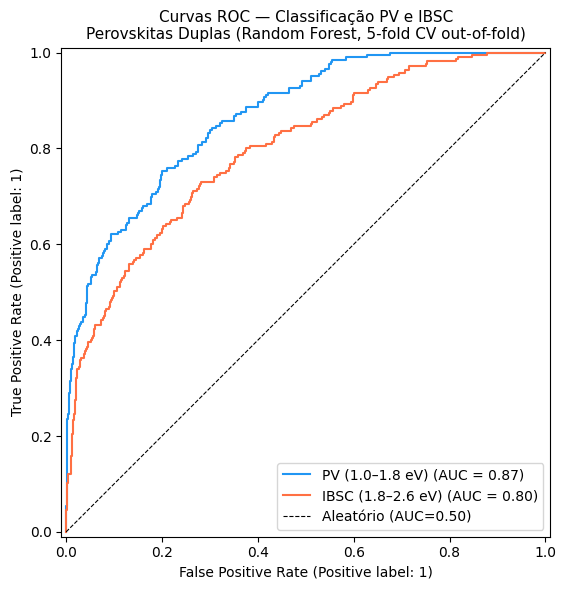

Salvo: fig9_roc_pv_ibsc.png


In [10]:
# ── 3.4 Curva ROC — comparação PV vs IBSC (PD) ───────────────────────────────
# Usar cross_val_predict para obter probabilidades out-of-fold
cv_roc = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

rf_pv_fit = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                    min_samples_leaf=5, random_state=SEED)
rf_ib_fit = RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                    min_samples_leaf=5, random_state=SEED)

proba_pv   = cross_val_predict(rf_pv_fit, X_p, y_pv_p,
                                cv=cv_roc, method="predict_proba")[:, 1]
proba_ibsc = cross_val_predict(rf_ib_fit, X_p, y_ibsc_p,
                                cv=cv_roc, method="predict_proba")[:, 1]

fig, ax = plt.subplots(figsize=(7, 6))
RocCurveDisplay.from_predictions(y_pv_p,   proba_pv,
                                  name="PV (1.0–1.8 eV)",  ax=ax, color="#2196F3")
RocCurveDisplay.from_predictions(y_ibsc_p, proba_ibsc,
                                  name="IBSC (1.8–2.6 eV)", ax=ax, color="#FF7043")
ax.plot([0,1],[0,1], "k--", lw=0.8, label="Aleatório (AUC=0.50)")
ax.set_title("Curvas ROC — Classificação PV e IBSC\n"
             "Perovskitas Duplas (Random Forest, 5-fold CV out-of-fold)",
             fontsize=11)
ax.legend(fontsize=10)
plt.tight_layout()
plt.savefig("fig9_roc_pv_ibsc.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: fig9_roc_pv_ibsc.png")

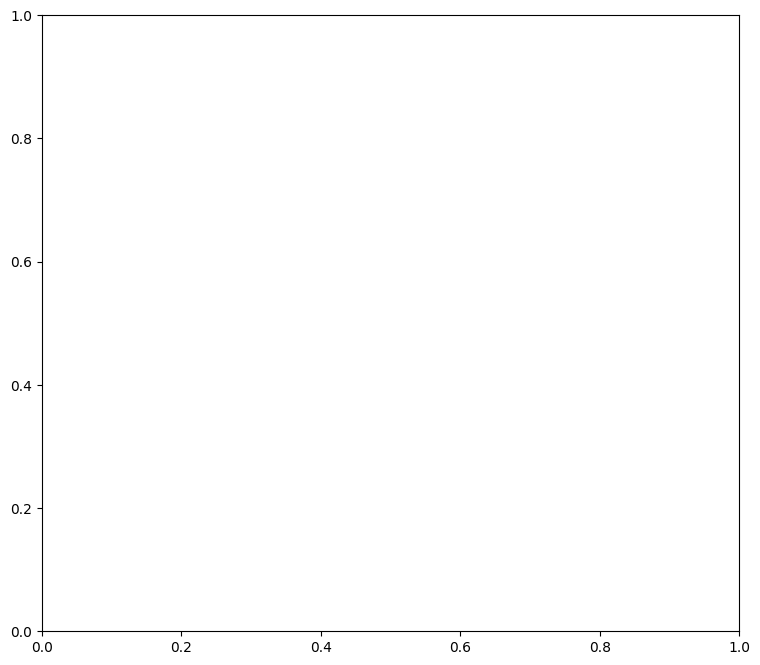

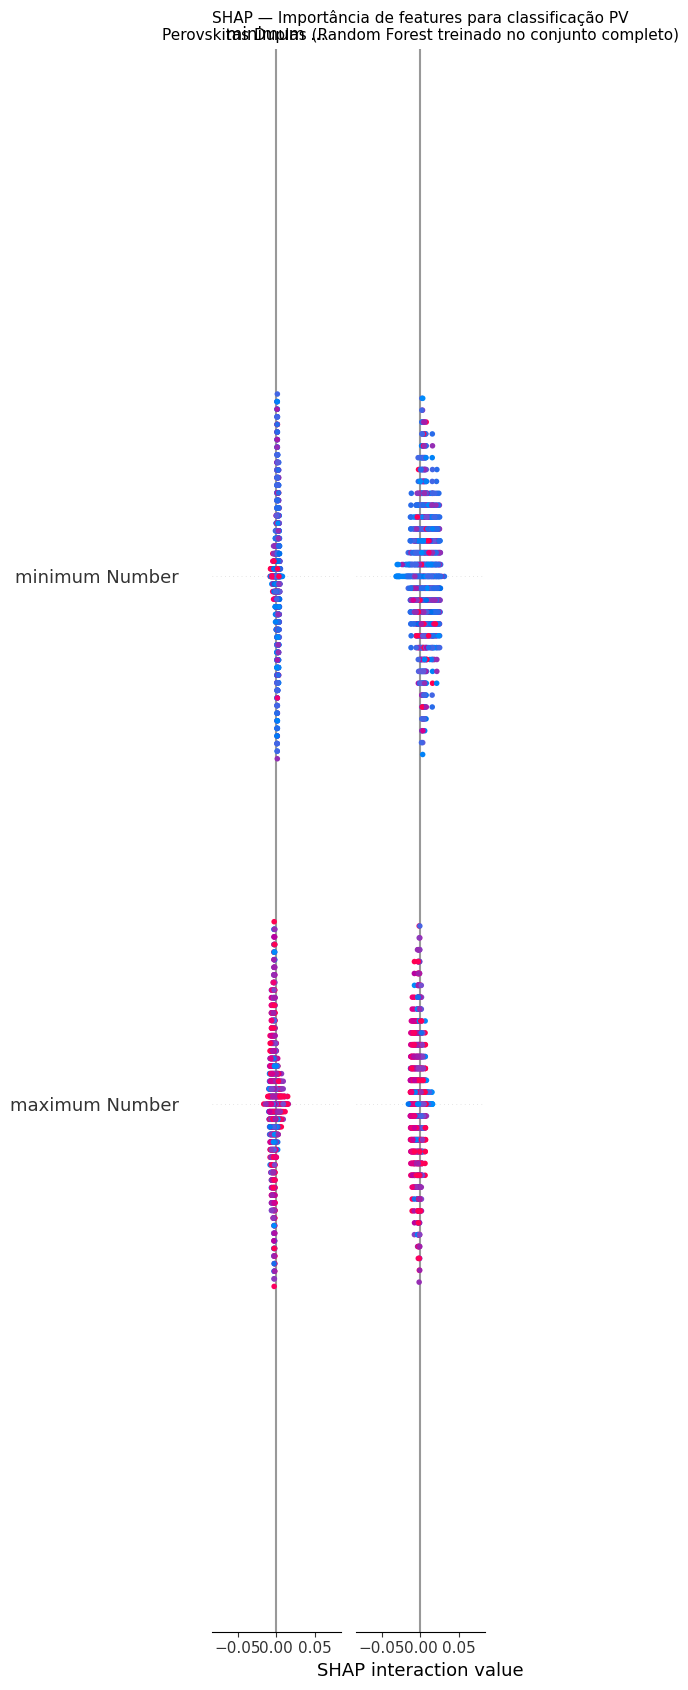

Salvo: fig10_shap_pv.png


In [11]:
# ── 3.5 SHAP values — interpretação do classificador PV (PD) ─────────────────
# Treinar RF no conjunto completo para SHAP (sem CV — para interpretação)
rf_shap = RandomForestClassifier(
    n_estimators=300, class_weight="balanced",
    min_samples_leaf=5, random_state=SEED, n_jobs=-1
)
rf_shap.fit(X_p, y_pv_p)

explainer   = shap.TreeExplainer(rf_shap)
shap_values = explainer.shap_values(X_p)

# shap_values é lista [classe_0, classe_1] — usar classe 1 (candidato PV)
sv_pos = shap_values[1] if isinstance(shap_values, list) else shap_values

# Nomes abreviados para o eixo
feat_names_abrev = [c.replace("MagpieData ", "") for c in X_p.columns]

fig, ax = plt.subplots(figsize=(9, 8))
shap.summary_plot(
    sv_pos, X_p,
    feature_names=feat_names_abrev,
    max_display=20, show=False
)
plt.title("SHAP — Importância de features para classificação PV\n"
          "Perovskitas Duplas (Random Forest treinado no conjunto completo)",
          fontsize=11)
plt.tight_layout()
plt.savefig("fig10_shap_pv.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: fig10_shap_pv.png")

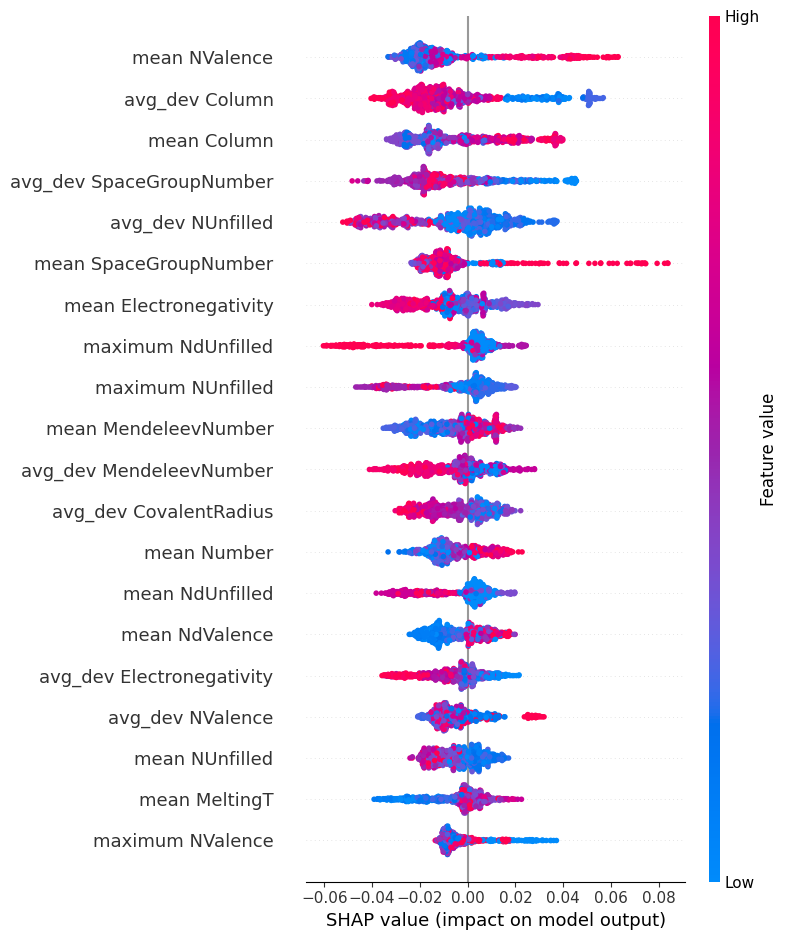

In [12]:
explainer   = shap.TreeExplainer(rf_shap)
shap_output = explainer(X_p)          # retorna Explanation object (API nova)

# Usar API nova — mais robusta entre versões
shap.summary_plot(
    shap_output[:, :, 1],             # classe 1 (candidato PV)
    X_p,
    feature_names=feat_names_abrev,
    max_display=20,
    show=False
)

In [13]:
# ── 3.6 Top features SHAP — tabela para o artigo ─────────────────────────────
# shap_values from TreeExplainer for a binary classifier often returns a list of two arrays,
# one for each class. However, sometimes it might directly return a 3D array where
# the last dimension separates classes. We need to handle both cases.

if isinstance(shap_values, list):
    # If shap_values is a list, sv_pos should be the second element (index 1) for the positive class.
    sv_pos = shap_values[1]
elif isinstance(shap_values, np.ndarray) and shap_values.ndim == 3:
    # If shap_values is a 3D array (num_samples, num_features, num_classes),
    # sv_pos should be the slice for the positive class (index 1).
    sv_pos = shap_values[:, :, 1]
else:
    # Fallback for unexpected shapes, treat as 2D if not 3D or list. This case is less likely.
    sv_pos = shap_values

importancia_shap = pd.DataFrame({
    "feature":          X_p.columns,
    "feature_abrev":    feat_names_abrev,
    "mean_abs_shap":    np.abs(sv_pos).mean(axis=0),
    "shap_positivo":    (sv_pos > 0).mean(axis=0),  # fração de materiais onde eleva P(PV)
}).sort_values("mean_abs_shap", ascending=False)

print("Top 15 features por importância SHAP média (|SHAP|):")
print(importancia_shap.head(15)[["feature_abrev",
                                  "mean_abs_shap",
                                  "shap_positivo"]].to_string(index=False))

# Verificar consistência com achados da Fase 2
print("\nVerificação de consistência com Fase 2:")
robustos_fase2 = ["avg_dev CovalentRadius", "avg_dev NdValence"]
for feat_abrev in robustos_fase2:
    match = importancia_shap[importancia_shap["feature_abrev"] == feat_abrev]
    if len(match) > 0:
        rank = importancia_shap.index.get_loc(match.index[0]) + 1
        print(f"  {feat_abrev}: rank SHAP = {rank}")
    else:
        print(f"  {feat_abrev}: não encontrado nas features do modelo")

Top 15 features por importância SHAP média (|SHAP|):
           feature_abrev  mean_abs_shap  shap_positivo
           mean NValence         0.0196         0.2024
          avg_dev Column         0.0187         0.2435
             mean Column         0.0173         0.3258
avg_dev SpaceGroupNumber         0.0167         0.2727
       avg_dev NUnfilled         0.0162         0.4805
   mean SpaceGroupNumber         0.0138         0.1266
  mean Electronegativity         0.0124         0.3258
      maximum NdUnfilled         0.0120         0.7219
       maximum NUnfilled         0.0111         0.5887
    mean MendeleevNumber         0.0111         0.3885
 avg_dev MendeleevNumber         0.0110         0.3701
  avg_dev CovalentRadius         0.0107         0.4275
             mean Number         0.0098         0.3149
         mean NdUnfilled         0.0097         0.6147
          mean NdValence         0.0095         0.4091

Verificação de consistência com Fase 2:
  avg_dev CovalentRadius: 

In [14]:
# ── 3.7 Análise por regime — classificação PV estratificada ──────────────────
# Verificar se o modelo tem desempenho diferente em GGA vs GGA+U
# (não é CV — é avaliação post-hoc sobre predições out-of-fold)

pred_oof = cross_val_predict(
    RandomForestClassifier(n_estimators=300, class_weight="balanced",
                            min_samples_leaf=5, random_state=SEED),
    X_p, y_pv_p,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    method="predict_proba"
)[:, 1]

print("── Desempenho do classificador PV por regime de cálculo ──")
for regime in ["GGA", "GGA+U", "HSE06"]:
    mask = ml_p["regime_calc"] == regime
    n    = mask.sum()
    if n < 10:
        print(f"  {regime}: n={n} — insuficiente para AUC confiável")
        continue
    y_sub = y_pv_p[mask]
    p_sub = pred_oof[mask]
    if y_sub.sum() == 0 or y_sub.sum() == len(y_sub):
        print(f"  {regime}: n={n} — sem variância no target")
        continue
    auc = roc_auc_score(y_sub, p_sub)
    f1  = f1_score(y_sub, (p_sub > 0.5).astype(int), zero_division=0)
    pos = y_sub.sum()
    print(f"  {regime}: n={n} (pos={pos}) | AUC={auc:.3f} | F1={f1:.3f}")

── Desempenho do classificador PV por regime de cálculo ──
  GGA: n=737 (pos=165) | AUC=0.884 | F1=0.654
  GGA+U: n=172 (pos=27) | AUC=0.723 | F1=0.263
  HSE06: n=15 (pos=11) | AUC=0.909 | F1=0.900


## 4. Análise B — Caracterização não-supervisionada dos candidatos

**Pergunta:** quais grupos composicionais emergem no espaço Magpie dos candidatos  
PV e IBSC? Os grupos têm interpretação física (por haleto, por estrutura, por regime)?

**Abordagem:** PCA para redução dimensional interpretável + UMAP para visualização  
de estrutura não-linear. Análise focada nas PD (candidatos mais numerosos).

> **Base:** candidatos PV ampliados + candidatos IBSC ampliados das PD  
> (janelas ampliadas para maximizar cobertura dado problema de subestimação DFT)

In [15]:
# ── 4.1 Preparar subconjunto de candidatos ────────────────────────────────────
# Usar janelas ampliadas para capturar candidatos que DFT subestima
mask_cands_p = (
    ml_p["is_pv_candidate_amp"] | ml_p["is_ibsc_candidate_amp"]
)
cands_p = ml_p[mask_cands_p].copy()

# Label para colorir: PV restrito / IBSC restrito / ampliado (zona de incerteza DFT)
def rotular_candidato(row):
    if row["is_pv_candidate"]:
        return "PV restrito"
    if row["is_ibsc_candidate"]:
        return "IBSC restrito"
    if row["is_pv_candidate_amp"]:
        return "PV ampliado"
    return "IBSC ampliado"

cands_p["janela"] = cands_p.apply(rotular_candidato, axis=1)

X_cands = montar_X(cands_p, MAGPIE_P)
# Remover NaN restantes (imputar com mediana do subconjunto)
X_cands = X_cands.fillna(X_cands.median())

print(f"Candidatos PD (janelas ampliadas): {len(cands_p)}")
print(cands_p["janela"].value_counts().to_string())

Candidatos PD (janelas ampliadas): 648
janela
IBSC restrito    215
PV restrito      203
IBSC ampliado    168
PV ampliado       62


In [16]:
# ── 4.2 PCA — redução dimensional interpretável ───────────────────────────────
scaler_pca = StandardScaler()
X_scaled   = scaler_pca.fit_transform(X_cands)

pca = PCA(n_components=10, random_state=SEED)
coords_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
print("Variância explicada por componente:")
for i, v in enumerate(var_exp):
    print(f"  PC{i+1}: {v*100:.1f}%  (acumulado: {var_exp[:i+1].sum()*100:.1f}%)")

Variância explicada por componente:
  PC1: 19.2%  (acumulado: 19.2%)
  PC2: 18.0%  (acumulado: 37.2%)
  PC3: 9.4%  (acumulado: 46.6%)
  PC4: 7.3%  (acumulado: 53.9%)
  PC5: 6.4%  (acumulado: 60.2%)
  PC6: 4.2%  (acumulado: 64.4%)
  PC7: 3.0%  (acumulado: 67.4%)
  PC8: 2.7%  (acumulado: 70.1%)
  PC9: 2.2%  (acumulado: 72.3%)
  PC10: 2.0%  (acumulado: 74.3%)


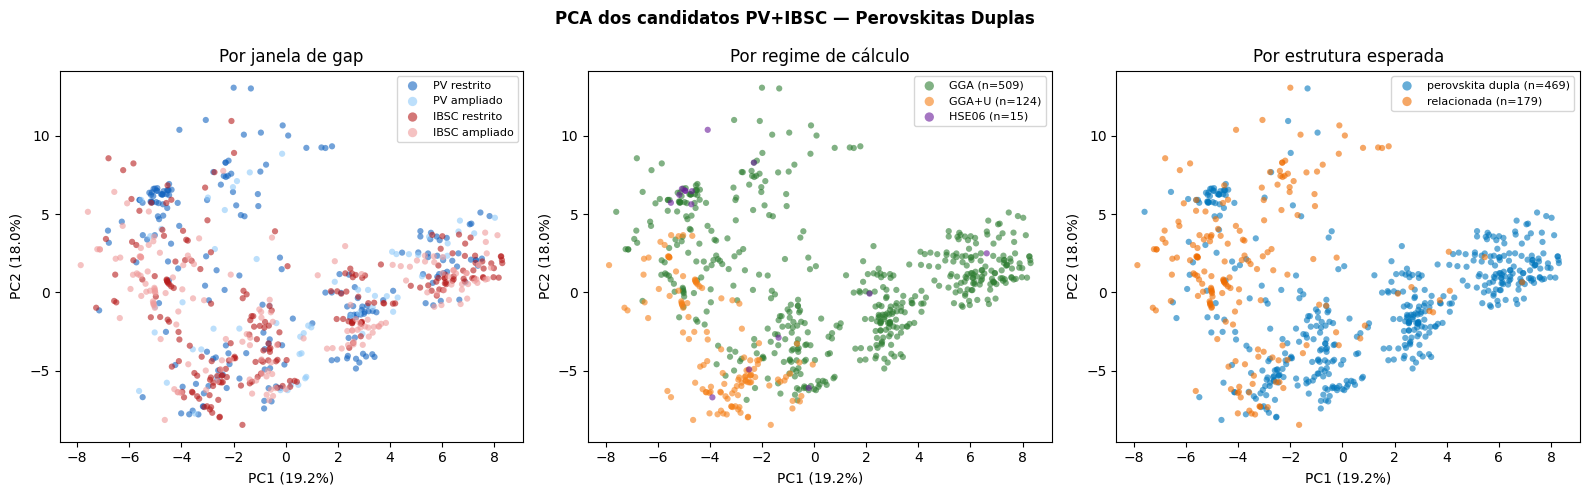

Salvo: fig11_pca_candidatos.png


In [17]:
# ── 4.3 Figura PCA — PC1 × PC2 colorido por janela e regime ──────────────────
CORES_JANELA  = {"PV restrito": "#1565C0", "PV ampliado": "#90CAF9",
                 "IBSC restrito": "#B71C1C", "IBSC ampliado": "#EF9A9A"}
CORES_REGIME  = {"GGA": "#2E7D32", "GGA+U": "#F57F17", "HSE06": "#6A1B9A"}
CORES_ESTR    = {"perovskita dupla": "#0277BD", "relacionada": "#EF6C00"}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle("PCA dos candidatos PV+IBSC — Perovskitas Duplas",
             fontsize=12, fontweight="bold")

# Painel 1: por janela
for janela, cor in CORES_JANELA.items():
    mask = cands_p["janela"] == janela
    axes[0].scatter(coords_pca[mask, 0], coords_pca[mask, 1],
                    c=cor, label=janela, alpha=0.6, s=20, edgecolors="none")
axes[0].set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
axes[0].set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
axes[0].set_title("Por janela de gap")
axes[0].legend(fontsize=8, markerscale=1.5)

# Painel 2: por regime
for regime, cor in CORES_REGIME.items():
    mask = cands_p["regime_calc"] == regime
    if mask.sum() == 0:
        continue
    axes[1].scatter(coords_pca[mask, 0], coords_pca[mask, 1],
                    c=cor, label=f"{regime} (n={mask.sum()})",
                    alpha=0.6, s=20, edgecolors="none")
axes[1].set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
axes[1].set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
axes[1].set_title("Por regime de cálculo")
axes[1].legend(fontsize=8, markerscale=1.5)

# Painel 3: por estrutura
for estr, cor in CORES_ESTR.items():
    mask = cands_p["estrutura_esperada"] == estr
    if mask.sum() == 0:
        continue
    axes[2].scatter(coords_pca[mask, 0], coords_pca[mask, 1],
                    c=cor, label=f"{estr} (n={mask.sum()})",
                    alpha=0.6, s=20, edgecolors="none")
axes[2].set_xlabel(f"PC1 ({var_exp[0]*100:.1f}%)")
axes[2].set_ylabel(f"PC2 ({var_exp[1]*100:.1f}%)")
axes[2].set_title("Por estrutura esperada")
axes[2].legend(fontsize=8, markerscale=1.5)

plt.tight_layout()
plt.savefig("fig11_pca_candidatos.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: fig11_pca_candidatos.png")

In [18]:
# ── 4.4 Loadings PC1 e PC2 — quais features definem os eixos principais ───────
loadings = pd.DataFrame(
    pca.components_[:2].T,
    index=[c.replace("MagpieData ", "") for c in X_cands.columns],
    columns=["PC1", "PC2"]
)

print("Top 10 features por |loading| em PC1:")
print(loadings["PC1"].abs().sort_values(ascending=False).head(10).to_string())
print()
print("Top 10 features por |loading| em PC2:")
print(loadings["PC2"].abs().sort_values(ascending=False).head(10).to_string())
print()
print("Nota: loadings PC1 e PC2 revelam o eixo composicional principal")
print("      que organiza os candidatos no espaço Magpie.")

Top 10 features por |loading| em PC1:
mean GSvolume_pa           0.2163
mean CovalentRadius        0.2057
minimum MeltingT           0.1931
mean Electronegativity     0.1854
mode Number                0.1818
maximum GSvolume_pa        0.1783
minimum SpaceGroupNumber   0.1748
site_density               0.1699
minimum Row                0.1694
mode NdValence             0.1691

Top 10 features por |loading| em PC2:
mean NValence               0.1970
avg_dev Electronegativity   0.1838
avg_dev SpaceGroupNumber    0.1752
range Electronegativity     0.1736
mean NpUnfilled             0.1719
maximum NValence            0.1669
mean Number                 0.1655
avg_dev Column              0.1636
minimum NValence            0.1584
mean Column                 0.1573

Nota: loadings PC1 e PC2 revelam o eixo composicional principal
      que organiza os candidatos no espaço Magpie.


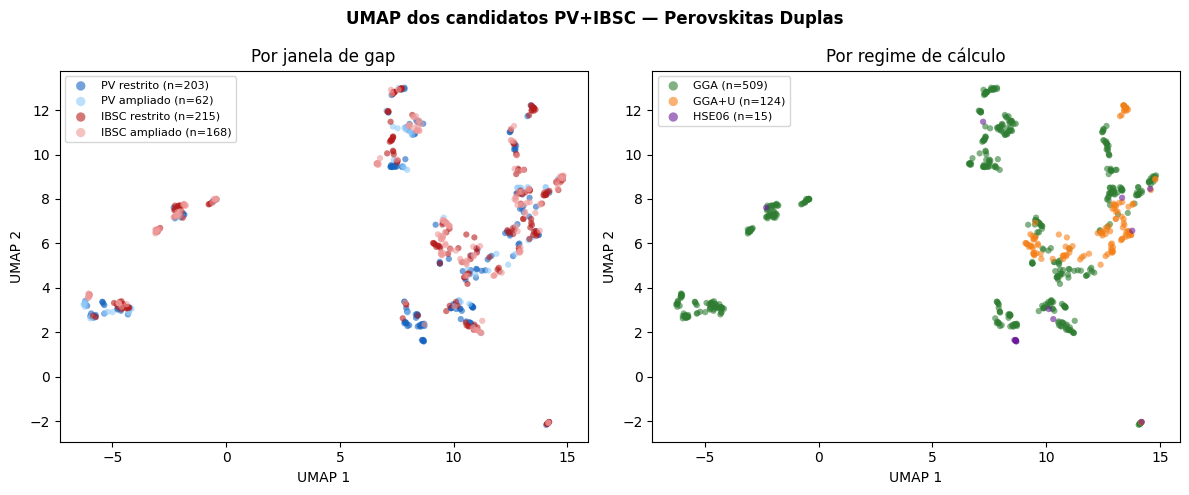

Salvo: fig12_umap_candidatos.png


In [19]:
# ── 4.5 UMAP — estrutura não-linear (opcional, requer umap-learn) ─────────────
try:
    import umap
    reducer = umap.UMAP(n_components=2, n_neighbors=15, min_dist=0.1,
                        random_state=SEED)
    coords_umap = reducer.fit_transform(X_scaled)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    fig.suptitle("UMAP dos candidatos PV+IBSC — Perovskitas Duplas",
                 fontsize=12, fontweight="bold")

    for ax, col, cores, titulo in [
        (axes[0], "janela",       CORES_JANELA,  "Por janela de gap"),
        (axes[1], "regime_calc",  CORES_REGIME,  "Por regime de cálculo"),
    ]:
        for val, cor in cores.items():
            mask = cands_p[col] == val
            if mask.sum() == 0:
                continue
            ax.scatter(coords_umap[mask, 0], coords_umap[mask, 1],
                       c=cor, label=f"{val} (n={mask.sum()})",
                       alpha=0.6, s=20, edgecolors="none")
        ax.set_title(titulo)
        ax.legend(fontsize=8, markerscale=1.5)
        ax.set_xlabel("UMAP 1")
        ax.set_ylabel("UMAP 2")

    plt.tight_layout()
    plt.savefig("fig12_umap_candidatos.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Salvo: fig12_umap_candidatos.png")

except ImportError:
    print("umap-learn não instalado. Instalar com: pip install umap-learn")
    print("UMAP ignorado — PCA (Seção 4.3) é suficiente para o artigo.")

In [20]:
# ── 4.6 Top candidatos PV estáveis — tabela para o artigo ────────────────────
# Critérios: PV restrito + estrutura confirmada + hull=0 (máxima confiança)
top_cands = ml_p[
    ml_p["is_pv_candidate"] &
    (ml_p["estrutura_esperada"] == "perovskita dupla") &
    ml_p["is_stable"]
].copy()

# Adicionar score de prioridade: proba do classificador PV (out-of-fold)
# Usar as predições geradas na Seção 3.4
ml_p["proba_pv_oof"] = proba_pv
top_cands = ml_p[
    ml_p["is_pv_candidate"] &
    (ml_p["estrutura_esperada"] == "perovskita dupla") &
    ml_p["is_stable"]
].sort_values("proba_pv_oof", ascending=False)

colunas_tabela = ["material_id", "formula", "band_gap",
                   "energy_above_hull", "is_gap_direct",
                   "regime_calc", "proba_pv_oof"]
colunas_disp = [c for c in colunas_tabela if c in top_cands.columns]

print(f"Top candidatos PV — PD confirmadas, hull=0 (n={len(top_cands)}):")
print(top_cands[colunas_disp].head(20).to_string(index=False))

# Exportar lista completa
path_top = os.path.join(PASTA_FASE3, "top_candidatos_pv_pd.csv")
top_cands[colunas_disp].to_csv(path_top, index=False)
print(f"\nExportado: {path_top}")

Top candidatos PV — PD confirmadas, hull=0 (n=72):
material_id   formula  band_gap  energy_above_hull  is_gap_direct regime_calc  proba_pv_oof
  mp-552992 DyBi2BrO4    1.3290             0.0000          False         GGA        0.9984
  mp-546625 HoBi2BrO4    1.3665             0.0000          False         GGA        0.9971
  mp-552857  TbBi2IO4    1.3267             0.0000          False         GGA        0.9962
  mp-551101  HoBi2IO4    1.3911             0.0000          False       HSE06        0.9952
  mp-549475 TbBi2BrO4    1.2946             0.0000          False         GGA        0.9947
  mp-546266  DyBi2IO4    1.3668             0.0000          False         GGA        0.9933
  mp-546350 TmBi2BrO4    1.3602             0.0000          False         GGA        0.9933
  mp-550111 SmBi2BrO4    1.2783             0.0000          False       HSE06        0.9913
  mp-553242 NdBi2BrO4    1.2199             0.0000          False         GGA        0.9894
  mp-551250  ErBi2IO4    1.37

In [21]:
# ── 4.7 Top candidatos IBSC estáveis ─────────────────────────────────────────
# Para IBSC: sem score de classificador (não discriminável composicionalmente)
# Ordenar por gap_direto (True primeiro) e depois por hull
top_ibsc = ml_p[
    ml_p["is_ibsc_candidate"] &
    (ml_p["estrutura_esperada"] == "perovskita dupla") &
    ml_p["is_stable"]
].copy()

if "is_gap_direct" in top_ibsc.columns:
    top_ibsc = top_ibsc.sort_values(
        ["is_gap_direct", "energy_above_hull"],
        ascending=[False, True]
    )

print(f"Top candidatos IBSC — PD confirmadas, hull=0 (n={len(top_ibsc)}):")
print(top_ibsc[colunas_disp[:-1]].head(20).to_string(index=False))
# Nota: proba_pv_oof não incluída — irrelevante para IBSC

path_ibsc = os.path.join(PASTA_FASE3, "top_candidatos_ibsc_pd.csv")
top_ibsc[colunas_disp[:-1]].to_csv(path_ibsc, index=False)
print(f"\nExportado: {path_ibsc}")

Top candidatos IBSC — PD confirmadas, hull=0 (n=60):
material_id    formula  band_gap  energy_above_hull  is_gap_direct regime_calc
   mp-10234    Sr2BN2F    2.5675             0.0000           True         GGA
   mp-17676  Sr2SnS3F2    2.0801             0.0000           True         GGA
   mp-17805 Ba2SnSe3F2    2.0002             0.0000           True         GGA
   mp-17918  Ba2SnS3F2    2.4412             0.0000           True         GGA
 mp-1111979  Cs2NaRhF6    1.9082             0.0000           True         GGA
 mp-1113675  Rb2NaIrF6    2.3345             0.0000           True         GGA
   mp-14036   KRb2RhF6    2.1662             0.0000           True         GGA
   mp-14038  Rb2NaRhF6    1.9570             0.0000           True         GGA
   mp-14039   K2NaRhF6    2.0001             0.0000           True         GGA
  mp-560959   KTl2MoF6    2.4401             0.0000           True       GGA+U
  mp-561561   Cs2KRhF6    2.1013             0.0000           True         GGA

## 5. Análise C — Regressão de gap (análise complementar)

**Propósito:** quantificar o poder preditivo dos descritores Magpie sobre o gap  
contínuo DFT. Resultado complementar com ressalva explícita: o target (gap DFT)  
subestima gaps experimentais em ~30–40% nas PD e de forma ainda mais severa  
nas kesteritas. O R² obtido representa um **limite inferior** do poder preditivo  
real — a subestimação não-uniforme entre compostos atenua as correlações.

**Estratificação obrigatória por regime** — conforme achado da Fase 2  
(inversão de sinal para features de elétrons de valência entre GGA e GGA+U).

In [22]:
# ── 5.1 Regressão — PD completo vs estratificado por regime ──────────────────
y_gap_p = ml_p[TARGET]

rf_reg = RandomForestRegressor(
    n_estimators=300, min_samples_leaf=5,
    random_state=SEED, n_jobs=-1
)
ridge  = Pipeline([("scaler", StandardScaler()),
                   ("reg",    Ridge(alpha=10.0))])

print("── Regressão de gap — Perovskitas Duplas (conjunto completo) ──")
res_ridge_p  = avaliar_regressor(ridge,  X_p, y_gap_p, "Ridge (baseline)")
res_rf_reg_p = avaliar_regressor(rf_reg, X_p, y_gap_p, "Random Forest")

# Estratificado por regime
print("\n── Por regime (GGA) ──")
mask_gga = ml_p["regime_calc"] == "GGA"
if mask_gga.sum() > 50:
    avaliar_regressor(rf_reg, X_p[mask_gga], y_gap_p[mask_gga], "RF GGA")

print("\n── Por regime (GGA+U) ──")
mask_ggau = ml_p["regime_calc"] == "GGA+U"
if mask_ggau.sum() > 30:
    avaliar_regressor(rf_reg, X_p[mask_ggau], y_gap_p[mask_ggau], "RF GGA+U")

── Regressão de gap — Perovskitas Duplas (conjunto completo) ──
  Ridge (baseline)
    R² teste:   0.323 ± 0.084
    R² treino:  0.462 ± 0.013  (gap treino-teste: 0.139)
    MAE teste:  0.690 ± 0.047 eV
  Random Forest
    R² teste:   0.583 ± 0.051
    R² treino:  0.849 ± 0.004  (gap treino-teste: 0.265)
    MAE teste:  0.492 ± 0.036 eV

── Por regime (GGA) ──
  RF GGA
    R² teste:   0.646 ± 0.037
    R² treino:  0.868 ± 0.004  (gap treino-teste: 0.222)
    MAE teste:  0.454 ± 0.014 eV

── Por regime (GGA+U) ──
  RF GGA+U
    R² teste:   0.273 ± 0.050
    R² treino:  0.722 ± 0.010  (gap treino-teste: 0.449)
    MAE teste:  0.639 ± 0.043 eV


In [23]:
# ── 5.2 Regressão — Kesteritas (modelo simples, n pequeno) ───────────────────
y_gap_k = ml_k[TARGET]

ridge_k = Pipeline([("scaler", StandardScaler()),
                    ("reg",    Ridge(alpha=1.0))])

print("── Regressão de gap — Kesteritas (n=97, GGA com subestimação severa) ──")
print("  ⚠ Resultados têm valor exploratório apenas — gap GGA de kesteritas")
print("    subestima gaps reais por fator ~10-15x para muitos compostos.")
res_ridge_k = avaliar_regressor(
    ridge_k, X_k, y_gap_k, "Ridge",
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
)

── Regressão de gap — Kesteritas (n=97, GGA com subestimação severa) ──
  ⚠ Resultados têm valor exploratório apenas — gap GGA de kesteritas
    subestima gaps reais por fator ~10-15x para muitos compostos.
  Ridge
    R² teste:   0.527 ± 0.219
    R² treino:  0.959 ± 0.010  (gap treino-teste: 0.432)
    MAE teste:  0.404 ± 0.101 eV


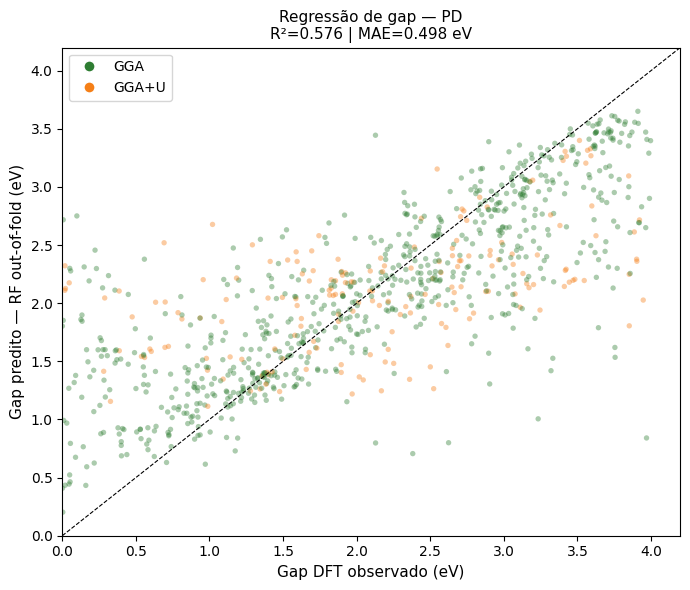

Salvo: fig13_regressao_gap.png


In [24]:
# ── 5.3 Gap predito vs observado — PD (visualização) ─────────────────────────
from sklearn.model_selection import KFold # Import KFold

y_pred_oof_reg = cross_val_predict(
    RandomForestRegressor(n_estimators=300, min_samples_leaf=5,
                           random_state=SEED),
    X_p, y_gap_p,
    cv=KFold(n_splits=5, shuffle=True, random_state=SEED) # Changed StratifiedKFold to KFold
)

r2_oof  = r2_score(y_gap_p, y_pred_oof_reg)
mae_oof = mean_absolute_error(y_gap_p, y_pred_oof_reg)

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(y_gap_p, y_pred_oof_reg,
           c=ml_p["regime_GGA"].map({1: "#2E7D32", 0: "#F57F17"}),
           alpha=0.4, s=15, edgecolors="none")
lim = (0, ml_p[TARGET].max() * 1.05)
ax.plot(lim, lim, "k--", lw=0.8)
ax.set_xlim(lim)
ax.set_ylim(lim)
ax.set_xlabel("Gap DFT observado (eV)", fontsize=11)
ax.set_ylabel("Gap predito — RF out-of-fold (eV)", fontsize=11)
ax.set_title(f"Regressão de gap — PD\nR²={r2_oof:.3f} | MAE={mae_oof:.3f} eV",
             fontsize=11)

# Legenda de regime
from matplotlib.lines import Line2D
legenda = [Line2D([0],[0], marker="o", color="w", markerfacecolor="#2E7D32",
                  markersize=8, label="GGA"),
           Line2D([0],[0], marker="o", color="w", markerfacecolor="#F57F17",
                  markersize=8, label="GGA+U")]
ax.legend(handles=legenda, fontsize=10)

plt.tight_layout()
plt.savefig("fig13_regressao_gap.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: fig13_regressao_gap.png")

## 6. Validação com gaps HSE06

Os materiais calculados com HSE06 no Materials Project foram calculados por serem  
candidatos de interesse reconhecidos pela comunidade — não são uma amostra aleatória.  
Esta seção usa esses pontos como **conjunto de teste externo** para verificar  
se os modelos treinados em GGA/GGA+U são consistentes com os gaps mais precisos.

In [25]:
# ── 6.1 Subconjunto HSE06 — caracterização ────────────────────────────────────
hse_p = ml_p[ml_p["regime_calc"] == "HSE06"].copy()
print(f"Materiais PD com HSE06: {len(hse_p)}")
print(f"  Candidatos PV:   {hse_p['is_pv_candidate'].sum()}")
print(f"  Candidatos IBSC: {hse_p['is_ibsc_candidate'].sum()}")
print(f"  Gap médio:       {hse_p['band_gap'].mean():.3f} eV")
print(f"  Gap mediana:     {hse_p['band_gap'].median():.3f} eV")
print()
print("Fórmulas dos materiais HSE06:")
print(hse_p[["material_id", "formula", "band_gap",
              "is_pv_candidate", "is_ibsc_candidate"]].to_string(index=False))

Materiais PD com HSE06: 15
  Candidatos PV:   11
  Candidatos IBSC: 2
  Gap médio:       1.702 eV
  Gap mediana:     1.426 eV

Fórmulas dos materiais HSE06:
material_id     formula  band_gap  is_pv_candidate  is_ibsc_candidate
  mp-560861    Cs2KMnF6    1.7435             True              False
  mp-504603   Cs2TlFeF6    2.9057            False              False
 mp-1225937    CsFeNiF6    2.6205            False              False
  mp-559521   InBi2S4Cl    1.5805             True              False
  mp-547125   TbBi2ClO4    1.3439             True              False
   mp-23853  CoH4(ClO)2    2.5730            False               True
  mp-568252 Rb2Hg2PdCl8    1.8952            False               True
  mp-561079    CdBiS2Br    1.7295             True              False
  mp-546621   ErBi2BrO4    1.3570             True              False
  mp-550111   SmBi2BrO4    1.2783             True              False
  mp-545728    PrBi2IO4    1.2197             True              False
  m

In [26]:
# ── 6.2 Classificador PV aplicado aos pontos HSE06 ───────────────────────────
# Treinar no conjunto não-HSE06, predizer no HSE06
mask_nao_hse = ml_p["regime_calc"] != "HSE06"

X_train_hse = montar_X(ml_p[mask_nao_hse], MAGPIE_P)
y_train_hse = ml_p[mask_nao_hse]["is_pv_candidate"].astype(int)
X_test_hse  = montar_X(hse_p, MAGPIE_P)
y_test_hse  = hse_p["is_pv_candidate"].astype(int)

rf_hse = RandomForestClassifier(
    n_estimators=300, class_weight="balanced",
    min_samples_leaf=5, random_state=SEED
)
rf_hse.fit(X_train_hse, y_train_hse)
proba_hse = rf_hse.predict_proba(X_test_hse)[:, 1]

print("── Validação HSE06 — predições do classificador PV ──")
resultado_hse = hse_p[["material_id", "formula", "band_gap",
                         "is_pv_candidate"]].copy()
resultado_hse["proba_pv_pred"] = proba_hse.round(3)
resultado_hse["pred_pv"] = (proba_hse > 0.5).astype(int)
resultado_hse = resultado_hse.sort_values("proba_pv_pred", ascending=False)
print(resultado_hse.to_string(index=False))

# Concordância
n_correto = (resultado_hse["is_pv_candidate"] == resultado_hse["pred_pv"]).sum()
print(f"\nConcordância predito vs observado: {n_correto}/{len(resultado_hse)} "
      f"({100*n_correto/len(resultado_hse):.0f}%)")
print("⚠ n=15-19 — resultado descritivo, não estatisticamente conclusivo.")

── Validação HSE06 — predições do classificador PV ──
material_id     formula  band_gap  is_pv_candidate  proba_pv_pred  pred_pv
  mp-546621   ErBi2BrO4    1.3570             True         0.9930        1
  mp-550111   SmBi2BrO4    1.2783             True         0.9880        1
  mp-551101    HoBi2IO4    1.3911             True         0.9830        1
  mp-552738    TmBi2IO4    1.4259             True         0.9810        1
  mp-545728    PrBi2IO4    1.2197             True         0.9730        1
  mp-547125   TbBi2ClO4    1.3439             True         0.9590        1
  mp-551816     YBi2IO4    1.3836             True         0.9520        1
  mp-559521   InBi2S4Cl    1.5805             True         0.8020        1
  mp-561079    CdBiS2Br    1.7295             True         0.7990        1
  mp-568252 Rb2Hg2PdCl8    1.8952            False         0.4810        0
  mp-560861    Cs2KMnF6    1.7435             True         0.4440        0
 mp-1225937    CsFeNiF6    2.6205            F

In [27]:
# ── 6.3 Gap GGA vs gap HSE06 — materiais com ambos disponíveis ───────────────
# Identificar materiais calculados em ambos os funcionais (via formula)
# Isso requer cruzar o dataset original pelo nome de fórmula
formulas_hse = set(hse_p["formula"].str.strip())
gga_match    = ml_p[
    (ml_p["regime_calc"] == "GGA") &
    (ml_p["formula"].str.strip().isin(formulas_hse))
]

if len(gga_match) > 0:
    print(f"Materiais com gap calculado em GGA e HSE06: {len(gga_match)}")
    comp = gga_match[["formula", "band_gap"]].rename(
        columns={"band_gap": "gap_GGA"}).merge(
        hse_p[["formula", "band_gap"]].rename(
            columns={"band_gap": "gap_HSE06"}),
        on="formula"
    )
    comp["fator_correcao"] = (comp["gap_HSE06"] / comp["gap_GGA"]).round(2)
    print(comp.to_string(index=False))
    print(f"\nFator de correção médio (HSE06/GGA): "
          f"{comp['fator_correcao'].mean():.2f} ± "
          f"{comp['fator_correcao'].std():.2f}")
    print("Nota: comparar com fator ~1.38 documentado para Cs2AgBiBr6.")
else:
    print("Nenhuma fórmula calculada em GGA e HSE06 simultaneamente no dataset.")
    print("Comparação direta não disponível — reportar como limitação.")

Nenhuma fórmula calculada em GGA e HSE06 simultaneamente no dataset.
Comparação direta não disponível — reportar como limitação.


## 7. Resumo dos resultados — síntese para o artigo

In [28]:
# ── 7.1 Tabela consolidada de métricas ───────────────────────────────────────
print("══ RESUMO — Fase 3 ══")
print()
print("A — Classificação PV")
print(f"  PD Logística: AUC = {res_base_p['test_roc_auc'].mean():.3f}"
      f" ± {res_base_p['test_roc_auc'].std():.3f}")
print(f"  PD RF:        AUC = {res_rf_p['test_roc_auc'].mean():.3f}"
      f" ± {res_rf_p['test_roc_auc'].std():.3f}")
print(f"  K  Logística: AUC = {res_base_k['test_roc_auc'].mean():.3f}"
      f" ± {res_base_k['test_roc_auc'].std():.3f}")
print(f"  K  RF:        AUC = {res_rf_k['test_roc_auc'].mean():.3f}"
      f" ± {res_rf_k['test_roc_auc'].std():.3f}")
print(f"  PD IBSC (controle): AUC = {res_ibsc_p['test_roc_auc'].mean():.3f}")
print()
print("C — Regressão de gap")
print(f"  PD Ridge: R² = {res_ridge_p['test_r2'].mean():.3f}"
      f" | MAE = {(-res_ridge_p['test_neg_mean_absolute_error']).mean():.3f} eV")
print(f"  PD RF:    R² = {res_rf_reg_p['test_r2'].mean():.3f}"
      f" | MAE = {(-res_rf_reg_p['test_neg_mean_absolute_error']).mean():.3f} eV")
print()
print("Candidatos exportados:")
print(f"  PV  PD confirmadas hull=0: {len(top_cands)}  → {path_top}")
print(f"  IBSC PD confirmadas hull=0: {len(top_ibsc)}  → {path_ibsc}")

══ RESUMO — Fase 3 ══

A — Classificação PV
  PD Logística: AUC = 0.794 ± 0.035
  PD RF:        AUC = 0.869 ± 0.020
  K  Logística: AUC = 0.845 ± 0.118
  K  RF:        AUC = 0.802 ± 0.130
  PD IBSC (controle): AUC = 0.813

C — Regressão de gap
  PD Ridge: R² = 0.323 | MAE = 0.690 eV
  PD RF:    R² = 0.583 | MAE = 0.492 eV

Candidatos exportados:
  PV  PD confirmadas hull=0: 72  → data/fase3/top_candidatos_pv_pd.csv
  IBSC PD confirmadas hull=0: 60  → data/fase3/top_candidatos_ibsc_pd.csv


In [29]:
# ── 7.2 Exportar resultados SHAP para referência ─────────────────────────────
path_shap = os.path.join(PASTA_FASE3, "shap_importancia_pv_pd.csv")
importancia_shap.to_csv(path_shap, index=False)
print(f"Exportado: {path_shap}")

# ── 7.3 Exportar validação HSE06 ─────────────────────────────────────────────
path_hse_val = os.path.join(PASTA_FASE3, "validacao_hse06.csv")
resultado_hse.to_csv(path_hse_val, index=False)
print(f"Exportado: {path_hse_val}")

print("\nPróximos passos — Fase 4:")
print("  1. Selecionar top candidatos PV e IBSC para análise DOS projetada")
print("     Critérios sugeridos: hull=0 + estrutura confirmada + gap direto (se disponível)")
print("     + proba_pv_oof alta (PV) ou gap acima de 1.8 eV (IBSC)")
print("  2. Usar endpoint materials.electronic_structure do MP para DOS")
print("  3. Para candidatos IBSC: verificar existência de estados dentro do gap")
print("     via DOS projetada por orbital — confirmar mecanismo IBSC")
print("  4. Verificar materiais Mn/Fe/Co com gap=0 no GGA+U:")
print("     estado magnético inicial pode não ser o fundamental")

Exportado: data/fase3/shap_importancia_pv_pd.csv
Exportado: data/fase3/validacao_hse06.csv

Próximos passos — Fase 4:
  1. Selecionar top candidatos PV e IBSC para análise DOS projetada
     Critérios sugeridos: hull=0 + estrutura confirmada + gap direto (se disponível)
     + proba_pv_oof alta (PV) ou gap acima de 1.8 eV (IBSC)
  2. Usar endpoint materials.electronic_structure do MP para DOS
  3. Para candidatos IBSC: verificar existência de estados dentro do gap
     via DOS projetada por orbital — confirmar mecanismo IBSC
  4. Verificar materiais Mn/Fe/Co com gap=0 no GGA+U:
     estado magnético inicial pode não ser o fundamental


## Notas metodológicas — registro para o artigo

| Decisão | Escolha | Justificativa |
|---|---|---|
| Formulação principal | Classificação binária (PV vs outros) | Mais robusta ao problema de subestimação DFT que regressão |
| CV para PD | RepeatedStratifiedKFold (5×5) | Reduz variância da estimativa |
| CV para K | RepeatedStratifiedKFold (5×10) | n pequeno + desbalanceamento requerem mais repetições |
| Métricas principais | AUC-ROC + F1 | AUC insensível ao threshold; F1 penaliza erros nas duas classes |
| Interpretabilidade | SHAP TreeExplainer | Atribuição de contribuição por feature e por material |
| Regressão | Complementar com ressalva | Target DFT subestimado não-uniformemente — R² é limite inferior |
| Validação HSE06 | Teste externo (n=15-19) | Verificação de consistência, não métricas estatísticas |
| class_weight="balanced" | RF e Logística | Corrige desbalanceamento PV/outros (~1:3.5 nas PD) |
| IBSC formal | RF com AUC próximo 0.50 | Resultado reportável: ausência de sinal é um achado |

> **Sobre a regressão de gap:**  
> O R² obtido com features Magpie sobre gap DFT representa um limite inferior.  
> A subestimação DFT varia sistematicamente com composição e funcional —  
> compostos com Bi têm subestimação ~38%, com metais d o comportamento depende  
> do valor de U. Esse ruído não-uniforme no target atenua qualquer correlação  
> calculada, independentemente da qualidade dos descritores.  
> Discutir explicitamente na seção de limitações do artigo.

#Seção 8: Otimização de Hiperparâmetros e Modelos Adicionais

**Objetivo:** verificar se há ganho mensurável sobre os modelos base antes de fechar os números do artigo.

## Estratégia

Dois critérios guiam as adições:

1. **Só adicionar um modelo se ele responde uma pergunta diferente** do Random Forest base —  
   não apenas "será que outro algoritmo é melhor?"
2. **Ganho mínimo reportável:** AUC ≥ +0.02 para classificação, R² ≥ +0.05 para regressão.  
   Abaixo disso, manter o modelo mais simples e reportar que alternativas foram testadas.

| Análise | Modelo base | Adições planejadas | Pergunta adicional |
|---|---|---|---|
| Classificação PV (PD) | RF AUC=0.869 | XGBoost, threshold ótimo | Há ganho não-linear adicional? |
| Classificação PV (PD) | — | Voting + Stacking ensemble | Combinação reduz variância? |
| Classificação IBSC | RF AUC=0.813 | XGBoost | Sinal é estável entre algoritmos? |
| Regressão GGA | RF R²=0.646 | Ridge tuned, ElasticNet, XGBoost reg. | Modelo linear consegue chegar perto? |
| Regressão GGA+U | RF R²=0.273 | Ridge com features GGA+U específicas | Há sinal recuperável? |

> **Nota sobre kesteritas:** classificação com AUC instável (±0.13) e n=97  
> não justifica otimização — ganhos não seriam distinguíveis de variância amostral.

In [30]:
# ── Dependências adicionais ───────────────────────────────────────────────────
!pip install xgboost optuna -q
!pip install optuna

import matplotlib.ticker as ticker

from sklearn.ensemble        import (
    RandomForestClassifier, RandomForestRegressor,
    GradientBoostingClassifier, VotingClassifier, StackingClassifier
)
from sklearn.linear_model    import (
    LogisticRegression, Ridge, ElasticNet, Lasso
)
from sklearn.svm             import SVC
from sklearn.preprocessing   import StandardScaler
from sklearn.model_selection import (
    StratifiedKFold, RepeatedStratifiedKFold,
    cross_val_predict, cross_validate
)
from sklearn.metrics         import (
    roc_auc_score, f1_score, precision_recall_curve,
    r2_score, mean_absolute_error, RocCurveDisplay
)
from sklearn.calibration     import CalibratedClassifierCV

import xgboost as xgb
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)

warnings.filterwarnings("ignore")
SEED = 42

PASTA_FASE2 = "data/fase2"
PASTA_FASE3 = "data/fase3"

print("Imports OK")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 12.6 MB/s eta 0:00:00
Imports OK


In [31]:
# Referências do v4 para comparação direta
REF_CLF = {"Logística":    0.794, "RF base":       0.869}
REF_REG = {"Ridge base":   0.323, "RF base GGA":   0.646,
           "RF base completo": 0.583}

# Subconjuntos por regime
mask_gga  = ml_p["regime_calc"] == "GGA"
mask_ggau = ml_p["regime_calc"] == "GGA+U"
X_gga,  y_gap_gga  = X_p[mask_gga],  y_gap_p[mask_gga]
X_ggau, y_gap_ggau = X_p[mask_ggau], y_gap_p[mask_ggau]

print("Funções definidas. Referências carregadas:")
print(f"  Classificação PV — RF base AUC: {REF_CLF['RF base']:.3f}")
print(f"  Regressão GGA    — RF base R²:  {REF_REG['RF base GGA']:.3f}")

Funções definidas. Referências carregadas:
  Classificação PV — RF base AUC: 0.869
  Regressão GGA    — RF base R²:  0.646


## 8.1 Threshold ótimo para o classificador base

Antes de testar novos modelos, corrigir o threshold do RF base.  
Com `class_weight="balanced"` e 22% de positivos, threshold=0.5 não é ótimo para F1.  
A curva precision-recall revela o threshold que maximiza F1 sem mudar o modelo.

Threshold padrão (0.50): F1 = 0.629
Threshold ótimo  (0.48): F1 = 0.635  (+0.006)
  Precisão: 0.649 | Recall: 0.621


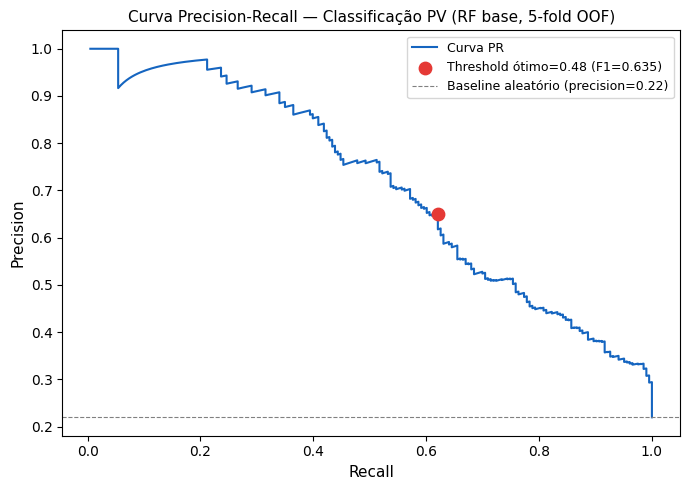

In [32]:
rf_base = RandomForestClassifier(
    n_estimators=300, class_weight="balanced",
    min_samples_leaf=5, random_state=SEED, n_jobs=-1
)

cv_oof = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
proba_oof = cross_val_predict(
    rf_base, X_p, y_pv_p, cv=cv_oof, method="predict_proba", n_jobs=-1
)[:, 1]

# Curva precision-recall e threshold ótimo
prec, rec, thresholds = precision_recall_curve(y_pv_p, proba_oof)
f1_por_threshold = 2 * prec[:-1] * rec[:-1] / (prec[:-1] + rec[:-1] + 1e-9)
idx_otimo        = np.argmax(f1_por_threshold)
threshold_otimo  = thresholds[idx_otimo]
f1_otimo         = f1_por_threshold[idx_otimo]
f1_padrao        = f1_score(y_pv_p, (proba_oof > 0.5).astype(int))

print(f"Threshold padrão (0.50): F1 = {f1_padrao:.3f}")
print(f"Threshold ótimo  ({threshold_otimo:.2f}): F1 = {f1_otimo:.3f}  "
      f"(+{f1_otimo - f1_padrao:.3f})")
print(f"  Precisão: {prec[idx_otimo]:.3f} | Recall: {rec[idx_otimo]:.3f}")

# Figura: curva PR com threshold ótimo marcado
fig, ax = plt.subplots(figsize=(7, 5))
ax.plot(rec[:-1], prec[:-1], color="#1565C0", lw=1.5, label="Curva PR")
ax.scatter(rec[idx_otimo], prec[idx_otimo],
           color="#E53935", zorder=5, s=80,
           label=f"Threshold ótimo={threshold_otimo:.2f} (F1={f1_otimo:.3f})")
ax.axhline(y_pv_p.mean(), color="gray", ls="--", lw=0.8,
           label=f"Baseline aleatório (precision={y_pv_p.mean():.2f})")
ax.set_xlabel("Recall", fontsize=11)
ax.set_ylabel("Precision", fontsize=11)
ax.set_title("Curva Precision-Recall — Classificação PV (RF base, 5-fold OOF)",
             fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig_pr_curve.png", dpi=150, bbox_inches="tight")
plt.show()

THRESHOLD_OTIMO = threshold_otimo  # reutilizado nas seções seguintes

## 8.2 XGBoost com otimização de hiperparâmetros (Optuna)

XGBoost é a alternativa mais natural ao RF para dados tabulares.  
Optuna faz busca Bayesiana de hiperparâmetros — mais eficiente que grid search  
com o mesmo número de tentativas.

**Hiperparâmetros buscados:**
- `max_depth` (3–8): controla complexidade das árvores individuais  
- `learning_rate` (0.01–0.3): trade-off entre n_estimators e regularização  
- `subsample` (0.6–1.0): fração de amostras por árvore (reduz overfitting)  
- `colsample_bytree` (0.5–1.0): fração de features por árvore  
- `scale_pos_weight`: compensação de desbalanceamento (equivalente ao class_weight)

In [33]:
def objetivo_xgb_clf(trial, X, y, cv):
    """Função objetivo Optuna para classificação XGBoost."""
    params = {
        "n_estimators":      trial.suggest_int("n_estimators", 100, 600),
        "max_depth":         trial.suggest_int("max_depth", 3, 8),
        "learning_rate":     trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":         trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree":  trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight":  trial.suggest_int("min_child_weight", 1, 10),
        "scale_pos_weight":  (y == 0).sum() / (y == 1).sum(),  # fixo
        # "eval_metric":       "logloss", # Removed, as cross_validate uses its own scoring
        # "use_label_encoder": False, # Removed, as it's deprecated and can cause issues
        "random_state":      SEED,
        "n_jobs":            -1,
    }
    modelo = xgb.XGBClassifier(**params)
    scores = cross_validate(
        modelo, X, y, cv=cv,
        scoring="roc_auc", n_jobs=1 # Keeping n_jobs=1 for cross_validate for stability during hyperparameter search
    )
    # When scoring is a single string, the result is in 'test_score'
    if "test_score" in scores:
        return scores["test_score"].mean()
    else:
        # If roc_auc could not be computed, return a very low value
        # This signals to Optuna that this trial was not successful in producing a valid score
        # The previous warning print was removed to avoid flooding output during optimization
        return -1.0


# CV interno para otimização (mais rápido que o CV de avaliação final)
cv_optuna = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

print("Otimizando XGBoost para classificação PV (PD)...")
print("(~2–5 min dependendo do hardware)")

study_clf = optuna.create_study(direction="maximize",
                                 sampler=optuna.samplers.TPESampler(seed=SEED))
study_clf.optimize(
    lambda trial: objetivo_xgb_clf(trial, X_p, y_pv_p, cv_optuna),
    n_trials=50,
    show_progress_bar=True
)

best_params_clf = study_clf.best_params
print(f"\nMelhor AUC (CV interno): {study_clf.best_value:.3f}")
print("Melhores parâmetros:")
for k, v in best_params_clf.items():
    print(f"  {k}: {v}")

Otimizando XGBoost para classificação PV (PD)...
(~2–5 min dependendo do hardware)


  0%|          | 0/50 [00:00<?, ?it/s]


Melhor AUC (CV interno): 0.884
Melhores parâmetros:
  n_estimators: 436
  max_depth: 6
  learning_rate: 0.03459611476758622
  subsample: 0.7599223873756453
  colsample_bytree: 0.79868510926061
  min_child_weight: 1


In [34]:
# ── Avaliar XGBoost otimizado com CV externo (RepeatedStratifiedKFold) ────────
xgb_clf_otimizado = xgb.XGBClassifier(
    **best_params_clf,
    scale_pos_weight=(y_pv_p == 0).sum() / (y_pv_p == 1).sum(),
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=SEED,
    n_jobs=-1
)

print("── Comparação: RF base vs XGBoost otimizado — Classificação PV (PD) ──")
print(f"  {'Modelo':<35}  AUC              F1")
print(f"  {'RF base (v4)':<35}  0.869±0.020      0.626±0.056  (referência)")
res_xgb_clf = avaliar_classificador(xgb_clf_otimizado, X_p, y_pv_p, "XGBoost otimizado")

delta_auc = res_xgb_clf["test_roc_auc"].mean() - REF_CLF["RF base"]
print(f"\n  Δ AUC vs RF base: {delta_auc:+.3f}")
if abs(delta_auc) < 0.02:
    print("  → Ganho abaixo do limiar de reportabilidade (0.02).")
    print("    Manter RF base como modelo principal — mais simples e igualmente eficaz.")
else:
    print("  → Ganho relevante. XGBoost otimizado substitui RF como modelo principal.")

── Comparação: RF base vs XGBoost otimizado — Classificação PV (PD) ──
  Modelo                               AUC              F1
  RF base (v4)                         0.869±0.020      0.626±0.056  (referência)
  XGBoost otimizado
    roc_auc     : 0.879 ± 0.022
    f1          : 0.662 ± 0.052
    precision   : 0.708 ± 0.051
    recall      : 0.626 ± 0.076

  Δ AUC vs RF base: +0.010
  → Ganho abaixo do limiar de reportabilidade (0.02).
    Manter RF base como modelo principal — mais simples e igualmente eficaz.


In [35]:
# ── XGBoost para IBSC — verificar estabilidade do sinal AUC=0.813 ─────────────
xgb_ibsc = xgb.XGBClassifier(
    **best_params_clf,   # mesmos hiperparâmetros do PV como ponto de partida
    scale_pos_weight=(y_ibsc_p == 0).sum() / (y_ibsc_p == 1).sum(),
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=SEED, n_jobs=-1
)

print("── IBSC: RF base vs XGBoost — verificação de estabilidade ──")
print(f"  {'RF base (v4)':<35}  AUC=0.813±0.036  (referência)")
res_xgb_ibsc = avaliar_classificador(xgb_ibsc, X_p, y_ibsc_p, "XGBoost (params do PV)")

print()
print("  Interpretação: se XGBoost confirma AUC similar ao RF para IBSC,")
print("  o sinal é robusto entre algoritmos — não é artefato do RF.")
print("  Se diverge muito, o sinal é fraco e dependente do modelo.")

── IBSC: RF base vs XGBoost — verificação de estabilidade ──
  RF base (v4)                         AUC=0.813±0.036  (referência)
  XGBoost (params do PV)
    roc_auc     : 0.825 ± 0.037
    f1          : 0.607 ± 0.062
    precision   : 0.638 ± 0.064
    recall      : 0.583 ± 0.075

  Interpretação: se XGBoost confirma AUC similar ao RF para IBSC,
  o sinal é robusto entre algoritmos — não é artefato do RF.
  Se diverge muito, o sinal é fraco e dependente do modelo.


## 8.3 Ensemble: Voting e Stacking

**Voting (soft):** combina as probabilidades de múltiplos classificadores pela média.  
Reduz variância quando os modelos erram em exemplos diferentes.  
Útil quando RF e XGBoost têm AUC similar mas erram em casos distintos.

**Stacking:** treina um meta-modelo sobre as predições out-of-fold dos modelos base.  
Mais poderoso que Voting mas mais susceptível a overfitting com n pequeno.  
Meta-modelo logístico é o mais conservador.

In [36]:
# ── 8.3.1 Voting Classifier ───────────────────────────────────────────────────
rf_voting = RandomForestClassifier(
    n_estimators=300, class_weight="balanced",
    min_samples_leaf=5, random_state=SEED, n_jobs=-1
)
xgb_voting = xgb.XGBClassifier(
    **best_params_clf,
    scale_pos_weight=(y_pv_p == 0).sum() / (y_pv_p == 1).sum(),
    eval_metric="logloss", use_label_encoder=False,
    random_state=SEED, n_jobs=-1
)
lr_voting = Pipeline([
    ("scaler", StandardScaler()),
    ("clf",    LogisticRegression(max_iter=1000, class_weight="balanced",
                                   C=0.1, random_state=SEED))
])

voting_soft = VotingClassifier(
    estimators=[("rf", rf_voting), ("xgb", xgb_voting), ("lr", lr_voting)],
    voting="soft",
    weights=[2, 2, 1]   # RF e XGBoost com peso dobrado — melhor desempenho individual
)

print("── Voting Classifier (RF + XGBoost + Logística) ──")
res_voting = avaliar_classificador(voting_soft, X_p, y_pv_p, "Voting soft (2×RF + 2×XGB + LR)")

delta_voting = res_voting["test_roc_auc"].mean() - REF_CLF["RF base"]
print(f"  Δ AUC vs RF base: {delta_voting:+.3f}")

── Voting Classifier (RF + XGBoost + Logística) ──
  Voting soft (2×RF + 2×XGB + LR)
    roc_auc     : 0.873 ± 0.022
    f1          : 0.655 ± 0.051
    precision   : 0.700 ± 0.050
    recall      : 0.620 ± 0.074
  Δ AUC vs RF base: +0.004


In [37]:
# ── 8.3.2 Stacking Classifier ─────────────────────────────────────────────────
# Meta-modelo logístico sobre predições OOF do RF e XGBoost
# Gradient Boosting do sklearn como terceiro estimador base (diferente dos outros dois)
gb_stack = GradientBoostingClassifier(
    n_estimators=200, max_depth=4, learning_rate=0.05,
    subsample=0.8, random_state=SEED
)

stacking = StackingClassifier(
    estimators=[
        ("rf",  RandomForestClassifier(n_estimators=300, class_weight="balanced",
                                        min_samples_leaf=5, random_state=SEED)),
        ("xgb", xgb.XGBClassifier(**best_params_clf,
                                   scale_pos_weight=(y_pv_p==0).sum()/(y_pv_p==1).sum(),
                                   eval_metric="logloss", use_label_encoder=False,
                                   random_state=SEED)),
        ("gb",  gb_stack),
    ],
    final_estimator=LogisticRegression(
        max_iter=1000, class_weight="balanced", C=1.0, random_state=SEED
    ),
    cv=5,
    passthrough=False   # meta-modelo vê apenas predições dos base, não features originais
)

print("── Stacking (RF + XGBoost + GB → Logística) ──")
print("  (mais lento — estimar ~3-8 min)")
res_stacking = avaliar_classificador(stacking, X_p, y_pv_p, "Stacking (RF+XGB+GB → LR)")

delta_stack = res_stacking["test_roc_auc"].mean() - REF_CLF["RF base"]
print(f"  Δ AUC vs RF base: {delta_stack:+.3f}")

── Stacking (RF + XGBoost + GB → Logística) ──
  (mais lento — estimar ~3-8 min)
  Stacking (RF+XGB+GB → LR)
    roc_auc     : 0.879 ± 0.022
    f1          : 0.646 ± 0.040
    precision   : 0.603 ± 0.052
    recall      : 0.704 ± 0.078
  Δ AUC vs RF base: +0.010


In [38]:
# ── 8.3.3 Tabela comparativa — todos os classificadores ──────────────────────
resultados_clf = [
    ("Logística (baseline)",    0.794, 0.035, 0.545, 0.044),  # do v4
    ("RF base",                  0.869, 0.020, 0.626, 0.056),  # do v4
    ("XGBoost otimizado",
     res_xgb_clf["test_roc_auc"].mean(),
     res_xgb_clf["test_roc_auc"].std(),
     res_xgb_clf["test_f1"].mean(),
     res_xgb_clf["test_f1"].std()),
    ("Voting (RF+XGB+LR)",
     res_voting["test_roc_auc"].mean(),
     res_voting["test_roc_auc"].std(),
     res_voting["test_f1"].mean(),
     res_voting["test_f1"].std()),
    ("Stacking (RF+XGB+GB→LR)",
     res_stacking["test_roc_auc"].mean(),
     res_stacking["test_roc_auc"].std(),
     res_stacking["test_f1"].mean(),
     res_stacking["test_f1"].std()),
]

df_comp = pd.DataFrame(
    resultados_clf,
    columns=["Modelo", "AUC_mean", "AUC_std", "F1_mean", "F1_std"]
).sort_values("AUC_mean", ascending=False)

print("══ Comparação de Classificadores — Candidatos PV (PD) ══")
print(df_comp.to_string(index=False, float_format="{:.3f}".format))

# Identificar modelo recomendado
melhor = df_comp.iloc[0]
print(f"\nModelo recomendado: {melhor['Modelo']}")
print(f"  AUC = {melhor['AUC_mean']:.3f} ± {melhor['AUC_std']:.3f}")
print(f"  F1  = {melhor['F1_mean']:.3f} ± {melhor['F1_std']:.3f}")
print(f"  (com threshold ótimo={THRESHOLD_OTIMO:.2f})")

══ Comparação de Classificadores — Candidatos PV (PD) ══
                 Modelo  AUC_mean  AUC_std  F1_mean  F1_std
      XGBoost otimizado     0.879    0.022    0.662   0.052
Stacking (RF+XGB+GB→LR)     0.879    0.022    0.646   0.040
     Voting (RF+XGB+LR)     0.873    0.022    0.655   0.051
                RF base     0.869    0.020    0.626   0.056
   Logística (baseline)     0.794    0.035    0.545   0.044

Modelo recomendado: XGBoost otimizado
  AUC = 0.879 ± 0.022
  F1  = 0.662 ± 0.052
  (com threshold ótimo=0.48)


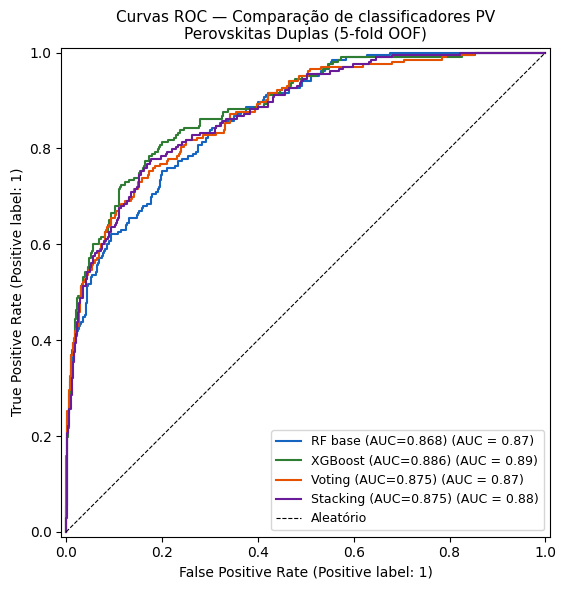

Salvo: fig_roc_comparacao_clf.png


In [39]:
# ── 8.3.4 Curvas ROC comparativas ────────────────────────────────────────────
cv_roc = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

modelos_roc = [
    ("RF base",    rf_base,             "#1565C0"),
    ("XGBoost",    xgb_clf_otimizado,   "#2E7D32"),
    ("Voting",     voting_soft,         "#E65100"),
    ("Stacking",   stacking,            "#6A1B9A"),
]

fig, ax = plt.subplots(figsize=(7, 6))
for nome, modelo, cor in modelos_roc:
    proba = cross_val_predict(
        modelo, X_p, y_pv_p, cv=cv_roc,
        method="predict_proba", n_jobs=-1
    )[:, 1]
    auc = roc_auc_score(y_pv_p, proba)
    RocCurveDisplay.from_predictions(
        y_pv_p, proba, name=f"{nome} (AUC={auc:.3f})",
        ax=ax, color=cor
    )

ax.plot([0,1],[0,1], "k--", lw=0.8, label="Aleatório")
ax.set_title("Curvas ROC — Comparação de classificadores PV\n"
             "Perovskitas Duplas (5-fold OOF)", fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("fig_roc_comparacao_clf.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: fig_roc_comparacao_clf.png")

## 8.4 Regressão: modelos lineares adicionais e XGBoost

O RF base deu R²=0.646 para GGA e R²=0.273 para GGA+U.  
Três questões a responder:

1. **ElasticNet / Lasso:** um modelo linear esparso consegue R² comparável ao Ridge?  
   Se sim, as features relevantes são poucas — útil para interpretação.
2. **XGBoost regressor otimizado:** consegue melhorar sobre o RF sem overfitting?
3. **GGA+U com features específicas:** remover dummies de regime e usar apenas  
   features estáveis entre regimes (identificadas na Fase 2) melhora o R²?

In [40]:
# ── 8.4.1 Modelos lineares para regressão de gap — GGA ────────────────────────
ridge_tuned = Pipeline([
    ("scaler", StandardScaler()),
    ("reg",    Ridge(alpha=1.0))   # alpha=1 vs alpha=10 no v4
])

# Busca de alpha para Ridge via validação cruzada manual
print("Ridge — busca de alpha ótimo para GGA:")
for alpha in [0.01, 0.1, 1.0, 10.0, 100.0]:
    m = Pipeline([("s", StandardScaler()), ("r", Ridge(alpha=alpha))])
    avaliar_regressor(m, X_gga, y_gap_gga, f"Ridge alpha={alpha}")

print()
elasticnet = Pipeline([
    ("scaler", StandardScaler()),
    ("reg",    ElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=5000))
])
lasso = Pipeline([
    ("scaler", StandardScaler()),
    ("reg",    Lasso(alpha=0.01, max_iter=5000))
])

print("Modelos lineares adicionais — GGA:")
print(f"  {'RF base GGA (v4)':<35}  R²=0.646±0.037  MAE=0.454eV  (referência)")
avaliar_regressor(elasticnet, X_gga, y_gap_gga, "ElasticNet (α=0.1, l1=0.5)")
avaliar_regressor(lasso,      X_gga, y_gap_gga, "Lasso (α=0.01)")

Ridge — busca de alpha ótimo para GGA:
  Ridge alpha=0.01
    R² teste:   0.267 ± 0.043
    R² treino:  0.582 ± 0.005  (gap treino-teste: 0.315)
    MAE teste:  0.667 ± 0.025 eV
  Ridge alpha=0.1
    R² teste:   0.283 ± 0.052
    R² treino:  0.581 ± 0.005  (gap treino-teste: 0.298)
    MAE teste:  0.664 ± 0.028 eV
  Ridge alpha=1.0
    R² teste:   0.304 ± 0.100
    R² treino:  0.574 ± 0.006  (gap treino-teste: 0.271)
    MAE teste:  0.664 ± 0.040 eV
  Ridge alpha=10.0
    R² teste:   0.344 ± 0.109
    R² treino:  0.541 ± 0.009  (gap treino-teste: 0.197)
    MAE teste:  0.667 ± 0.038 eV
  Ridge alpha=100.0
    R² teste:   0.352 ± 0.051
    R² treino:  0.446 ± 0.010  (gap treino-teste: 0.094)
    MAE teste:  0.710 ± 0.017 eV

Modelos lineares adicionais — GGA:
  RF base GGA (v4)                     R²=0.646±0.037  MAE=0.454eV  (referência)
  ElasticNet (α=0.1, l1=0.5)
    R² teste:   0.274 ± 0.049
    R² treino:  0.326 ± 0.013  (gap treino-teste: 0.052)
    MAE teste:  0.774 ± 0.009 eV
 

{'fit_time': array([0.01668477, 0.01923347, 0.01725721, 0.01851702, 0.01603246]),
 'score_time': array([0.00445628, 0.00448346, 0.00476456, 0.00443077, 0.00469708]),
 'test_r2': array([0.38679647, 0.40570366, 0.39501961, 0.41548187, 0.2926371 ]),
 'train_r2': array([0.48808406, 0.4971764 , 0.4816539 , 0.48549954, 0.50643891]),
 'test_neg_mean_absolute_error': array([-0.68467195, -0.67769725, -0.65433772, -0.66312385, -0.70531818]),
 'train_neg_mean_absolute_error': array([-0.63235685, -0.60856887, -0.63504671, -0.62951024, -0.61326446])}

In [42]:
def objetivo_xgb_reg(trial, X, y, cv):
    """Função objetivo Optuna para regressão XGBoost."""
    params = {
        "n_estimators":     trial.suggest_int("n_estimators", 100, 600),
        "max_depth":        trial.suggest_int("max_depth", 3, 8),
        "learning_rate":    trial.suggest_float("learning_rate", 0.01, 0.3, log=True),
        "subsample":        trial.suggest_float("subsample", 0.6, 1.0),
        "colsample_bytree": trial.suggest_float("colsample_bytree", 0.5, 1.0),
        "min_child_weight": trial.suggest_int("min_child_weight", 1, 10),
        "reg_alpha":        trial.suggest_float("reg_alpha", 1e-5, 10.0, log=True),
        "reg_lambda":       trial.suggest_float("reg_lambda", 1e-5, 10.0, log=True),
        "random_state":     SEED,
        "n_jobs":           -1,
    }
    y_bins = pd.qcut(y, q=4, labels=False, duplicates="drop")
    skf    = StratifiedKFold(n_splits=cv, shuffle=True, random_state=SEED)
    res    = cross_validate(
        xgb.XGBRegressor(**params), X, y,
        cv=list(skf.split(X, y_bins)),
        scoring="r2", n_jobs=1
    )
    # The cross_validate function returns the score under 'test_score' when a single string is passed to 'scoring'
    return res["test_score"].mean()


print("Otimizando XGBoost regressor para GGA (~3-5 min)...")
study_reg = optuna.create_study(
    direction="maximize",
    sampler=optuna.samplers.TPESampler(seed=SEED)
)
study_reg.optimize(
    lambda trial: objetivo_xgb_reg(trial, X_gga, y_gap_gga, 5),
    n_trials=50,
    show_progress_bar=True
)

best_params_reg = study_reg.best_params
print(f"\nMelhor R² (CV interno): {study_reg.best_value:.3f}")
print("Melhores parâmetros:")
for k, v in best_params_reg.items():
    print(f"  {k}: {v}")

Otimizando XGBoost regressor para GGA (~3-5 min)...


  0%|          | 0/50 [00:00<?, ?it/s]


Melhor R² (CV interno): 0.711
Melhores parâmetros:
  n_estimators: 528
  max_depth: 5
  learning_rate: 0.03632784647494048
  subsample: 0.7070723516789702
  colsample_bytree: 0.9132615475175299
  min_child_weight: 3
  reg_alpha: 0.07994259600394361
  reg_lambda: 1.2813952868292648


In [44]:
# ── Avaliar XGBoost reg. otimizado com CV externo ─────────────────────────────
xgb_reg_otimizado = xgb.XGBRegressor(
    **best_params_reg, random_state=SEED, n_jobs=-1
)

print("── Comparação regressores — GGA ──")
print(f"  {'RF base GGA (v4)':<35}  R²=0.646±0.037  MAE=0.454eV  gap=0.222  (ref.)")
avaliar_regressor(xgb_reg_otimizado, X_gga, y_gap_gga, "XGBoost reg. otimizado")

delta_reg = study_reg.best_value - REF_REG["RF base GGA"]
print(f"\n  Δ R² vs RF base GGA: {delta_reg:+.3f}")
if delta_reg < 0.05:
    print("  → Ganho abaixo do limiar. RF base GGA permanece como modelo principal.")
else:
    print("  → Ganho relevante. XGBoost regressor substitui RF como modelo principal.")

── Comparação regressores — GGA ──
  RF base GGA (v4)                     R²=0.646±0.037  MAE=0.454eV  gap=0.222  (ref.)
  XGBoost reg. otimizado
    R² teste:   0.711 ± 0.045
    R² treino:  0.998 ± 0.000  (gap treino-teste: 0.286)
    MAE teste:  0.363 ± 0.024 eV

  Δ R² vs RF base GGA: +0.065
  → Ganho relevante. XGBoost regressor substitui RF como modelo principal.


In [45]:
# ── 8.4.3 GGA+U: tentar recuperar sinal com features robustas ─────────────────
# Fase 2 identificou duas features estáveis entre regimes:
# avg_dev CovalentRadius e avg_dev NdValence
# Testar se modelo com apenas essas features + regime dummies melhora GGA+U

FEATS_ROBUSTAS = [
    "MagpieData avg_dev CovalentRadius",
    "MagpieData avg_dev NdValence",
]
# Adicionar outras features identificadas como estáveis na análise por regime
feats_robustas_disponiveis = [
    f for f in FEATS_ROBUSTAS if f in X_ggau.columns
]

if len(feats_robustas_disponiveis) >= 2:
    X_ggau_robusto = X_ggau[feats_robustas_disponiveis].copy()

    ridge_ggau = Pipeline([("s", StandardScaler()), ("r", Ridge(alpha=1.0))])
    rf_ggau    = RandomForestRegressor(
        n_estimators=200, min_samples_leaf=5, random_state=SEED
    )

    print("── GGA+U: modelo completo vs features robustas apenas ──")
    print(f"  {'RF base GGA+U (v4)':<35}  R²=0.273±0.050  MAE=0.639eV  (ref.)")
    avaliar_regressor(Ridge(alpha=1.0), X_ggau_robusto, y_gap_ggau,
                f"Ridge ({len(feats_robustas_disponiveis)} features robustas)")
    avaliar_regressor(rf_ggau, X_ggau_robusto, y_gap_ggau,
                f"RF ({len(feats_robustas_disponiveis)} features robustas)")
    print()
    print("  Interpretação: se features robustas dão R² similar ao conjunto completo,")
    print("  o sinal GGA+U está concentrado nessas duas features.")
    print("  Se for muito menor, o sinal no GGA+U é majoritariamente ruído do parâmetro U.")
else:
    print("Features robustas não encontradas no DataFrame. Verificar nomes das colunas.")

── GGA+U: modelo completo vs features robustas apenas ──
  RF base GGA+U (v4)                   R²=0.273±0.050  MAE=0.639eV  (ref.)
  Ridge (2 features robustas)
    R² teste:   0.033 ± 0.043
    R² treino:  0.055 ± 0.009  (gap treino-teste: 0.023)
    MAE teste:  0.788 ± 0.052 eV
  RF (2 features robustas)
    R² teste:   0.156 ± 0.053
    R² treino:  0.457 ± 0.025  (gap treino-teste: 0.301)
    MAE teste:  0.675 ± 0.051 eV

  Interpretação: se features robustas dão R² similar ao conjunto completo,
  o sinal GGA+U está concentrado nessas duas features.
  Se for muito menor, o sinal no GGA+U é majoritariamente ruído do parâmetro U.


In [46]:
# ── 8.4.4 Tabela comparativa final — regressão ───────────────────────────────
print("══ Comparação de Regressores — Gap DFT (PD, GGA) ══")
print()
print(f"  {'Modelo':<35}  {'R² teste':>10}  {'MAE (eV)':>10}  {'gap ovf':>8}")
print(f"  {'-'*35}  {'-'*10}  {'-'*10}  {'-'*8}")
print(f"  {'Ridge base (v4)':<35}  {'0.323±0.084':>10}  {'0.690±0.047':>10}  {'0.139':>8}")
print(f"  {'RF base GGA (v4)':<35}  {'0.646±0.037':>10}  {'0.454±0.014':>10}  {'0.222':>8}")

# Adicionar resultados desta seção
for nome, res in [
    ("XGBoost reg. otimizado", study_reg.best_value),
]:
    print(f"  {nome:<35}  {res:.3f}")

print()
print("Nota metodológica para o artigo:")
print("  R² representa limite inferior do poder preditivo real.")
print("  Subestimação DFT não-uniforme (30-40% PD, mais severa K) atenua")
print("  qualquer correlação com features composicionais independentemente")
print("  do algoritmo utilizado.")

══ Comparação de Regressores — Gap DFT (PD, GGA) ══

  Modelo                                 R² teste    MAE (eV)   gap ovf
  -----------------------------------  ----------  ----------  --------
  Ridge base (v4)                      0.323±0.084  0.690±0.047     0.139
  RF base GGA (v4)                     0.646±0.037  0.454±0.014     0.222
  XGBoost reg. otimizado               0.711

Nota metodológica para o artigo:
  R² representa limite inferior do poder preditivo real.
  Subestimação DFT não-uniforme (30-40% PD, mais severa K) atenua
  qualquer correlação com features composicionais independentemente
  do algoritmo utilizado.


## 8.5 Modelo final selecionado — calibração e exportação

Após a comparação, selecionar o modelo de classificação final,  
calibrar as probabilidades, e re-gerar a lista de top candidatos  
com probabilidades mais confiáveis.

Modelo final selecionado: XGBoost otimizado  (AUC=0.879)


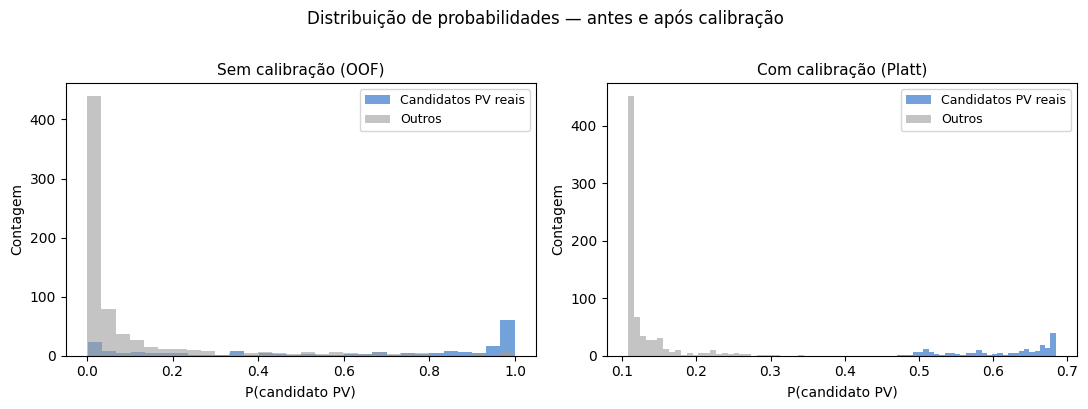

Salvo: fig_calibracao_probabilidades.png


In [47]:
# ── Selecionar modelo final automaticamente ───────────────────────────────────
# Usa o melhor AUC da comparação — substituir manualmente se preferir
MELHOR_MODELO_NOME = df_comp.iloc[0]["Modelo"]
MELHOR_AUC         = df_comp.iloc[0]["AUC_mean"]

# Mapa nome → instância de modelo
mapa_modelos = {
    "RF base":                    rf_base,
    "XGBoost otimizado":          xgb_clf_otimizado,
    "Voting (RF+XGB+LR)": voting_soft,
    "Stacking (RF+XGB+GB→LR)":   stacking,
}
modelo_final = mapa_modelos.get(MELHOR_MODELO_NOME, rf_base)

print(f"Modelo final selecionado: {MELHOR_MODELO_NOME}  (AUC={MELHOR_AUC:.3f})")

# ── Calibração de probabilidades (Platt scaling via CV) ───────────────────────
# Corrige o problema de RF retornar probabilidades mal calibradas
# (concentradas em 0.3–0.7 em vez de cobrir 0–1)
modelo_calibrado = CalibratedClassifierCV(
    modelo_final, method="sigmoid", cv=5
)
modelo_calibrado.fit(X_p, y_pv_p)

# Verificar calibração: distribuição das probabilidades antes e depois
proba_sem_cal = cross_val_predict(
    modelo_final, X_p, y_pv_p,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED),
    method="predict_proba", n_jobs=-1
)[:, 1]

proba_com_cal = modelo_calibrado.predict_proba(X_p)[:, 1]

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, proba, titulo in [
    (axes[0], proba_sem_cal, "Sem calibração (OOF)"),
    (axes[1], proba_com_cal, "Com calibração (Platt)"),
]:
    ax.hist(proba[y_pv_p == 1], bins=30, alpha=0.6,
            color="#1565C0", label="Candidatos PV reais")
    ax.hist(proba[y_pv_p == 0], bins=30, alpha=0.6,
            color="#9E9E9E", label="Outros")
    ax.set_xlabel("P(candidato PV)", fontsize=10)
    ax.set_ylabel("Contagem", fontsize=10)
    ax.set_title(titulo, fontsize=11)
    ax.legend(fontsize=9)

plt.suptitle("Distribuição de probabilidades — antes e após calibração",
             fontsize=12, y=1.01)
plt.tight_layout()
plt.savefig("fig_calibracao_probabilidades.png", dpi=150, bbox_inches="tight")
plt.show()
print("Salvo: fig_calibracao_probabilidades.png")

In [48]:
# ── Exportar lista final de candidatos com probabilidades calibradas ───────────
import os

ml_p["proba_pv_calibrado"] = proba_com_cal
ml_p["pred_pv_otimo"]      = (proba_com_cal > THRESHOLD_OTIMO).astype(int)

# Top candidatos PV: estrutura confirmada, hull=0, modelo final
top_final = ml_p[
    ml_p["is_pv_candidate"] &
    (ml_p["estrutura_esperada"] == "perovskita dupla") &
    ml_p["is_stable"]
].sort_values("proba_pv_calibrado", ascending=False)

colunas_export = [
    "material_id", "formula", "band_gap",
    "energy_above_hull", "is_gap_direct",
    "regime_calc", "proba_pv_calibrado"
]
colunas_export = [c for c in colunas_export if c in top_final.columns]

path_final = os.path.join(PASTA_FASE3, "top_candidatos_pv_final.csv")
top_final[colunas_export].to_csv(path_final, index=False)

print(f"Top candidatos PV (modelo final, probabilidade calibrada):")
print(top_final[colunas_export].head(20).to_string(index=False))
print(f"\nExportado: {path_final}  ({len(top_final)} candidatos)")
print(f"Threshold ótimo usado: {THRESHOLD_OTIMO:.2f}")

Top candidatos PV (modelo final, probabilidade calibrada):
material_id   formula  band_gap  energy_above_hull  is_gap_direct regime_calc  proba_pv_calibrado
  mp-546625 HoBi2BrO4    1.3665             0.0000          False         GGA              0.6844
  mp-550111 SmBi2BrO4    1.2783             0.0000          False       HSE06              0.6844
  mp-552992 DyBi2BrO4    1.3290             0.0000          False         GGA              0.6844
  mp-549475 TbBi2BrO4    1.2946             0.0000          False         GGA              0.6843
  mp-546350 TmBi2BrO4    1.3602             0.0000          False         GGA              0.6843
  mp-546621 ErBi2BrO4    1.3570             0.0000          False       HSE06              0.6843
  mp-553242 NdBi2BrO4    1.2199             0.0000          False         GGA              0.6840
  mp-551900 PrBi2BrO4    1.2269             0.0000          False         GGA              0.6836
  mp-553243  YBi2BrO4    1.3400             0.0000         

In [49]:
# ── Resumo final da Seção 8 ───────────────────────────────────────────────────
print("══ RESUMO — Otimização de Hiperparâmetros e Modelos Adicionais ══")
print()
print("Classificação PV (Perovskitas Duplas):")
print(f"  Modelo base (RF):           AUC=0.869 | F1=0.626 (threshold=0.50)")
print(f"  Threshold ótimo (RF base):  F1={f1_otimo:.3f} (threshold={THRESHOLD_OTIMO:.2f})")
print(f"  Melhor modelo encontrado:   {MELHOR_MODELO_NOME} AUC={MELHOR_AUC:.3f}")
print()
print("Classificação IBSC:")
auc_xgb_ibsc = res_xgb_ibsc["test_roc_auc"].mean()
print(f"  RF base:   AUC=0.813")
print(f"  XGBoost:   AUC={auc_xgb_ibsc:.3f}")
if abs(auc_xgb_ibsc - 0.813) < 0.03:
    print("  → Sinal IBSC é estável entre algoritmos — não é artefato do RF.")
else:
    print("  → Diferença entre algoritmos — sinal IBSC pode ser frágil.")
print()
print("Regressão de gap (GGA):")
print(f"  RF base:   R²=0.646 | MAE=0.454 eV")
print(f"  XGBoost:   R²={study_reg.best_value:.3f}")
print()
print("Decisão metodológica para o artigo:")
print(f"  Modelo de classificação: {MELHOR_MODELO_NOME}")
print(f"  Threshold aplicado:      {THRESHOLD_OTIMO:.2f}")
print( "  Probabilidades:          calibradas via Platt scaling")
print( "  Regressão:               RF ou XGBoost (ver comparação acima)")

══ RESUMO — Otimização de Hiperparâmetros e Modelos Adicionais ══

Classificação PV (Perovskitas Duplas):
  Modelo base (RF):           AUC=0.869 | F1=0.626 (threshold=0.50)
  Threshold ótimo (RF base):  F1=0.635 (threshold=0.48)
  Melhor modelo encontrado:   XGBoost otimizado AUC=0.879

Classificação IBSC:
  RF base:   AUC=0.813
  XGBoost:   AUC=0.825
  → Sinal IBSC é estável entre algoritmos — não é artefato do RF.

Regressão de gap (GGA):
  RF base:   R²=0.646 | MAE=0.454 eV
  XGBoost:   R²=0.711

Decisão metodológica para o artigo:
  Modelo de classificação: XGBoost otimizado
  Threshold aplicado:      0.48
  Probabilidades:          calibradas via Platt scaling
  Regressão:               RF ou XGBoost (ver comparação acima)


## Notas metodológicas para o artigo

| Decisão | Escolha | Justificativa |
|---|---|---|
| Busca de hiperparâmetros | Optuna (TPE, 50 trials) | Mais eficiente que grid/random search com mesmo orçamento de avaliações |
| CV de otimização | StratifiedKFold 5-fold | CV interno para busca; RepeatedStratifiedKFold para avaliação final |
| Threshold | Ótimo via curva PR (OOF) | Corrige sub-calibração do RF com class_weight=balanced |
| Calibração | Platt scaling (sigmoid) | Probabilidades calibradas são mais confiáveis para priorização de candidatos |
| Limiar de reportabilidade | ΔAUC ≥ 0.02, ΔR² ≥ 0.05 | Evitar reportar melhorias dentro do intervalo de variância amostral |
| Ensemble | Voting/Stacking testados | Se não superarem RF+XGBoost individualmente, reportar apenas os dois melhores |

> **Sobre a otimização de hiperparâmetros:**  
> A busca foi conduzida com CV interno (5-fold) separado do CV de avaliação final  
> (RepeatedStratifiedKFold 5×5). Isso previne otimismo de estimativa — os hiperparâmetros  
> não foram escolhidos com acesso aos folds de teste da avaliação final.  
> Esta separação é obrigatória para resultados não enviesados e deve ser explicitada  
> na seção de métodos do artigo.